# Capítulo 6 · Machine Learning — Ejercicios 6.12 (puntos 1, 3 y 4)

**Autor:** Juan · Ingeniería Mecatrónica, Universidad Nacional de Colombia · Octubre 2026
**Base:** guía *6. Introducción a Machine Learning* (J. J. Martínez) y los notebooks de clase *Estudio del algoritmo K-NN* y *Estudio del algoritmo Árboles de decisión* (J. Tellez, M. Caicedo).

| Parte | Contenido |
|---|---|
| **1. Ejercicio 1** | Aprender la multiplicación de matrices 2×2 a partir de 50.000 ejemplos, compararla con el cálculo analítico y medir el costo computacional |
| **2. Base común** | Diagnóstico y corrección del entorno Pong + Q-Learning de los notebooks de clase |
| **3. Ejercicio 3: K-NN** | Teoría detallada, implementación desde cero, aplicación a Pong y a datos del **ICFES (Saber 11, datos.gov.co)** |
| **4. Ejercicio 4: Árboles de decisión** | Teoría detallada (Gini, entropía, poda), implementación del *split* desde cero, aplicación a Pong y al ICFES |
| **5. Conclusiones** | Comparación de los modelos y discusión de “ML oscura” |

> **Datos gubernamentales:** según la guía, al menos uno de los ejercicios debe usar datos de una entidad del gobierno. En las secciones 3.5 y 4.5 se usan los **resultados de la prueba Saber 11 del ICFES**, publicados en el portal de datos abiertos del Estado colombiano (`datos.gov.co`, conjunto `kgxf-xxbe`). Esas celdas descargan los datos por la API Socrata, así que **requieren conexión a internet** (funcionan en Colab).

In [28]:
# ============================================================
# 0. Librerías y configuración general
# ============================================================
import time, random, io, os
from math import ceil, floor
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.pipeline import make_pipeline, Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.neural_network import MLPRegressor
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier, export_text, plot_tree
from sklearn.impute import SimpleImputer
from sklearn.dummy import DummyClassifier
from sklearn.inspection import permutation_importance
from sklearn.metrics import (r2_score, mean_absolute_error, accuracy_score, balanced_accuracy_score,
                             classification_report, confusion_matrix, ConfusionMatrixDisplay, roc_auc_score)

SEED = 42
np.random.seed(SEED); random.seed(SEED)
pd.set_option('display.width', 140)
plt.rcParams.update({'figure.dpi': 110, 'axes.grid': True, 'grid.alpha': .3})

---
# 1. Ejercicio 1 — ¿Puede un modelo de ML “aprender” a multiplicar matrices?

> *Considere la figura 6.1. Conforme un data set con resultados de 50.000 multiplicaciones de matrices 2×2, generadas aleatoriamente con números enteros entre −20 y 20. Una vez entrenado el modelo, úselo con 10 ejemplos y compare los resultados con los que se producen al realizar la operación analíticamente. Haga un cálculo de qué es más costoso computacionalmente.*

## 1.1 Planteamiento

La figura 6.1 contrasta dos caminos:

* **Programación tradicional:** `reglas + datos → respuestas`. Programamos la regla $C = AB$ y la evaluamos.
* **Machine Learning:** `datos + respuestas → reglas`. Damos 50.000 pares $(A,B) \rightarrow C$ y el modelo debe *inferir* la regla.

Para $A=\begin{pmatrix}a_{11}&a_{12}\\a_{21}&a_{22}\end{pmatrix}$ y $B=\begin{pmatrix}b_{11}&b_{12}\\b_{21}&b_{22}\end{pmatrix}$:

$$c_{11}=a_{11}b_{11}+a_{12}b_{21},\quad c_{12}=a_{11}b_{12}+a_{12}b_{22},\quad c_{21}=a_{21}b_{11}+a_{22}b_{21},\quad c_{22}=a_{21}b_{12}+a_{22}b_{22}$$

Es un problema de **regresión multisalida**: 8 entradas ($a_{ij}, b_{ij}$) y 4 salidas ($c_{ij}$). Cada salida es una **forma bilineal**, es decir, un polinomio de grado 2 de las entradas. Esto permite predecir qué modelo funcionará antes de entrenar:

| Modelo | Hipótesis | ¿Puede representar $C=AB$? |
|---|---|---|
| Regresión lineal | $\hat c = w^\top x + b$ | **No.** Como las entradas son independientes y de media cero, $\operatorname{Cov}(a_{11}b_{11}, a_{11}) = E[a_{11}^2]\,E[b_{11}] = 0$: ninguna entrada está correlacionada linealmente con la salida y se espera $R^2 \approx 0$. |
| Regresión polinómica de grado 2 | $\hat c = w^\top \phi(x)$, con $\phi$ = todos los monomios de grado ≤ 2 (45 *features*) | **Sí, de forma exacta.** Basta con que los coeficientes de $a_{11}b_{11}$ y $a_{12}b_{21}$ valgan 1 y los demás 0. |
| Red neuronal (MLP, ReLU) | Aproximador universal | **Solo aproximadamente:** una red ReLU es lineal a trozos, así que aproxima la superficie cuadrática con “facetas”. |

In [29]:
# ============================================================
# 1.2 Generación del dataset: 50.000 productos de matrices 2x2
# ============================================================
rng = np.random.default_rng(SEED)
N = 50_000
A = rng.integers(-20, 21, size=(N, 2, 2))      # enteros en [-20, 20] (21 es exclusivo)
B = rng.integers(-20, 21, size=(N, 2, 2))
Cm = A @ B                                     # "respuestas" obtenidas analíticamente

cols_in  = ['a11','a12','a21','a22','b11','b12','b21','b22']
cols_out = ['c11','c12','c21','c22']
X1 = np.hstack([A.reshape(N, 4), B.reshape(N, 4)]).astype(float)
Y1 = Cm.reshape(N, 4).astype(float)

df_mat = pd.DataFrame(np.hstack([X1, Y1]).astype(int), columns=cols_in + cols_out)
print(f"Dataset: {df_mat.shape[0]} filas x {df_mat.shape[1]} columnas")
print(df_mat.head().to_string())
print("\nRango de las salidas c_ij:", Y1.min(), "a", Y1.max(), "(teórico: ±800)")

X1_tr, X1_te, Y1_tr, Y1_te = train_test_split(X1, Y1, test_size=0.2, random_state=SEED)

Dataset: 50000 filas x 12 columnas
   a11  a12  a21  a22  b11  b12  b21  b22  c11  c12  c21  c22
0  -17   11    6   -3   20   18   19   18 -131 -108   63   54
1   -3   15  -17    8   16    1    8  -10   72 -153 -208  -97
2  -12  -17    1   20    8   10   -3    7  -45 -239  -52  150
3   10   11    9   12   -3   15  -12   14 -162  304 -171  303
4    1  -15   14   -2   11   -9  -14    3  221  -54  182 -132

Rango de las salidas c_ij: -780.0 a 761.0 (teórico: ±800)


## 1.3 Entrenamiento de tres modelos

* **Lineal:** sirve como línea base y para comprobar la hipótesis de que $R^2 \approx 0$.
* **Polinómico de grado 2:** `PolynomialFeatures(2)` seguido de mínimos cuadrados.
* **MLP:** dos capas ocultas de 128 neuronas ReLU. Las entradas se estandarizan y las salidas se dividen por 400 para que queden en un rango cercano a [−2, 2], lo que estabiliza el entrenamiento con Adam. Se usa *early stopping*.

Métricas: $R^2$, MAE y **% de productos exactos**, es decir, el porcentaje de casos en que, al redondear las 4 salidas al entero más cercano, se obtiene exactamente $C$. Esta última es la métrica relevante, porque la multiplicación es una operación exacta.

In [30]:
# ============================================================
# 1.3 Entrenamiento y evaluación
# ============================================================
ESCALA_Y = 400.0
modelos_mat = {
    'Lineal':          LinearRegression(),
    'Polinómico g=2':  make_pipeline(PolynomialFeatures(degree=2), LinearRegression()),
    'MLP (128,128)':   make_pipeline(StandardScaler(),
                                     MLPRegressor(hidden_layer_sizes=(128, 128), max_iter=200,
                                                  early_stopping=True, random_state=SEED)),
}
filas, t_fit = [], {}
for nombre, m in modelos_mat.items():
    escala = ESCALA_Y if 'MLP' in nombre else 1.0
    t0 = time.perf_counter(); m.fit(X1_tr, Y1_tr / escala); t_fit[nombre] = time.perf_counter() - t0
    P = m.predict(X1_te) * escala
    filas.append({'modelo': nombre, 'R2': r2_score(Y1_te, P), 'MAE': mean_absolute_error(Y1_te, P),
                  'error máx': np.abs(P - Y1_te).max(),
                  '% exactos (redondeo)': 100 * (np.round(P) == Y1_te).all(axis=1).mean(),
                  't_entrenamiento [s]': t_fit[nombre]})
res_mat = pd.DataFrame(filas).set_index('modelo')
print(res_mat.round(4).to_string())

                    R2       MAE  error máx  % exactos (redondeo)  t_entrenamiento [s]
modelo                                                                                
Lineal         -0.0002  154.8188   763.0007                   0.0               0.0210
Polinómico g=2  1.0000    0.0000     0.0000                 100.0               0.1303
MLP (128,128)   0.9975    7.6545    66.0610                   0.0              17.5703


In [31]:
# ============================================================
# 1.4 ¿Qué "regla" aprendió el modelo polinómico?  (Figura 6.1: datos + respuestas -> reglas)
# ============================================================
poly, lr = modelos_mat['Polinómico g=2'].named_steps.values()
nombres_feat = poly.get_feature_names_out(cols_in)
for j, c in enumerate(cols_out):
    w = lr.coef_[j]
    terminos = [f"{w[i]:+.6f}·{nombres_feat[i].replace(' ', '')}" for i in np.flatnonzero(np.abs(w) > 1e-6)]
    print(f"{c} = {lr.intercept_[j]:+.1e} " + " ".join(terminos))
print("\nNúmero de coeficientes con |w| > 1e-6:", int((np.abs(lr.coef_) > 1e-6).sum()), "de", lr.coef_.size)

c11 = -9.1e-14 +1.000000·a11b11 +1.000000·a12b21
c12 = +4.5e-14 +1.000000·a11b12 +1.000000·a12b22
c21 = -1.0e-14 +1.000000·a21b11 +1.000000·a22b21
c22 = -1.4e-14 +1.000000·a21b12 +1.000000·a22b22

Número de coeficientes con |w| > 1e-6: 8 de 180


El modelo polinómico **recuperó la regla exacta**: de los 180 coeficientes (45 *features* × 4 salidas), solo 8 son distintos de cero, valen 1 y corresponden exactamente a los productos de la definición de $AB$. Este es el caso ideal de la figura 6.1, en el que el modelo de ML obtiene las reglas a partir de los datos. Lo consigue porque se le dio el **sesgo inductivo correcto** (*features* de grado 2). La MLP, que no tiene ese sesgo, solo puede aproximar la regla.

## 1.5 Prueba con 10 ejemplos nuevos

Se generan 10 pares de matrices que no estaban en el dataset y se comparan los tres resultados: el analítico, el del modelo polinómico y el de la MLP.

In [32]:
# ============================================================
# 1.5 Diez ejemplos nuevos: modelo vs cálculo analítico
# ============================================================
rng10 = np.random.default_rng(2026)
A10 = rng10.integers(-20, 21, size=(10, 2, 2)); B10 = rng10.integers(-20, 21, size=(10, 2, 2))
X10 = np.hstack([A10.reshape(10, 4), B10.reshape(10, 4)]).astype(float)
C10 = (A10 @ B10).reshape(10, 4)                                         # analítico
P_poly = modelos_mat['Polinómico g=2'].predict(X10)
P_mlp  = modelos_mat['MLP (128,128)'].predict(X10) * ESCALA_Y

for i in range(10):
    print(f"Ej {i+1:2d}: A={A10[i].tolist()}  B={B10[i].tolist()}")
    print(f"        analítico : {C10[i].tolist()}")
    print(f"        polinómico: {np.round(P_poly[i], 6).tolist()}")
    print(f"        MLP       : {np.round(P_mlp[i], 1).tolist()}   |error| máx = {np.abs(P_mlp[i]-C10[i]).max():.1f}")

tabla10 = pd.DataFrame({
    'MAE polinómico': np.abs(P_poly - C10).mean(axis=1),
    'MAE MLP': np.abs(P_mlp - C10).mean(axis=1),
    'MLP exacto tras redondeo': (np.round(P_mlp) == C10).all(axis=1)}, index=[f'Ej {i+1}' for i in range(10)])
print('\n', tabla10.round(4).to_string())

Ej  1: A=[[14, -13], [-19, 6]]  B=[[15, 1], [-17, -3]]
        analítico : [431, 53, -387, -37]
        polinómico: [431.0, 53.0, -387.0, -37.0]
        MLP       : [425.8, 49.6, -391.4, -33.3]   |error| máx = 5.2
Ej  2: A=[[-6, -1], [-17, -5]]  B=[[-9, 7], [14, -20]]
        analítico : [40, -22, 83, -19]
        polinómico: [40.0, -22.0, 83.0, -19.0]
        MLP       : [31.3, -8.0, 93.1, 15.7]   |error| máx = 34.7
Ej  3: A=[[6, -6], [14, 12]]  B=[[-1, -2], [20, -6]]
        analítico : [-126, 24, 226, -100]
        polinómico: [-126.0, 24.0, 226.0, -100.0]
        MLP       : [-112.9, 29.2, 222.1, -105.0]   |error| máx = 13.1
Ej  4: A=[[8, 17], [9, -13]]  B=[[-14, -12], [-1, 4]]
        analítico : [-129, -28, -113, -160]
        polinómico: [-129.0, -28.0, -113.0, -160.0]
        MLP       : [-121.0, -27.7, -102.6, -160.6]   |error| máx = 10.4
Ej  5: A=[[15, 6], [-16, -8]]  B=[[-7, -3], [7, -8]]
        analítico : [-63, -93, 56, 112]
        polinómico: [-63.0, -93.0, 56.0, 112.0]

### Extrapolación: ¿qué pasa fuera del rango de entrenamiento?

Una prueba exigente para saber si un modelo aprendió la regla o solo memorizó la región de los datos es evaluarlo con enteros en $[-100, 100]$, un rango que nunca vio durante el entrenamiento.

In [6]:
rngx = np.random.default_rng(7)
Ax = rngx.integers(-100, 101, size=(2000, 2, 2)); Bx = rngx.integers(-100, 101, size=(2000, 2, 2))
Xx = np.hstack([Ax.reshape(-1, 4), Bx.reshape(-1, 4)]).astype(float); Cx = (Ax @ Bx).reshape(-1, 4)
for nombre in ['Polinómico g=2', 'MLP (128,128)']:
    esc = ESCALA_Y if 'MLP' in nombre else 1
    P = modelos_mat[nombre].predict(Xx) * esc
    print(f"{nombre:15s}  MAE = {mean_absolute_error(Cx, P):10.4f}   % exactos = {100*(np.round(P)==Cx).all(1).mean():6.2f} %")

Polinómico g=2   MAE =     0.0000   % exactos = 100.00 %
MLP (128,128)    MAE =  2552.1475   % exactos =   0.00 %


## 1.6 ¿Qué es más costoso computacionalmente?

### a) Conteo de operaciones de punto flotante (FLOPs) por **una** multiplicación

* **Analítica:** 8 multiplicaciones y 4 sumas, es decir, **12 FLOPs**.
* **Modelo polinómico:** construir $\phi(x)$ requiere 36 productos de grado 2. Luego hay un producto matriz–vector de $45 \times 4$, que son 180 multiplicaciones y 180 sumas, más 4 *intercepts*.
* **MLP:** $8\cdot128 + 128\cdot128 + 128\cdot4$ multiplicaciones-acumulaciones (MAC), cada una de 2 FLOPs. A eso se suman la estandarización (16 FLOPs), los *bias* y las ReLU.

### b) Costo de **entrenamiento** (se paga una sola vez)

* **Polinómico:** mínimos cuadrados con $n=40\,000$ y $p=45$ cuesta $\approx 2np^2 + p^3$ FLOPs.
* **MLP:** por época, forward + backward $\approx 3 \times$ (FLOPs del forward) × $n$.
* **Generar el dataset:** hay que calcular las 50.000 respuestas *analíticamente*, así que el enfoque de ML gasta las operaciones del método tradicional desde antes de empezar.

In [33]:
# ============================================================
# 1.6 Conteo de FLOPs (inferencia y entrenamiento)
# ============================================================
mlp = modelos_mat['MLP (128,128)'].named_steps['mlpregressor']
capas = [8] + list(mlp.hidden_layer_sizes) + [4]
macs_mlp = sum(a*b for a, b in zip(capas[:-1], capas[1:]))
flops = {
    'Analítico':      8 + 4,
    'Polinómico g=2': 36 + 2*45*4 + 4,
    'MLP (128,128)':  16 + 2*macs_mlp + sum(capas[1:]) + sum(capas[1:-1]),   # escalado + MACs + bias + ReLU
}
n_tr, p = X1_tr.shape[0], 45
flops_train = {
    'Analítico': 0,
    'Polinómico g=2': 2*n_tr*p**2 + p**3,
    'MLP (128,128)': 3 * 2*macs_mlp * n_tr * mlp.n_iter_,
}
tabla_costo = pd.DataFrame({'FLOPs por producto': flops,
                            'veces el analítico': {k: v/flops['Analítico'] for k, v in flops.items()},
                            'FLOPs de entrenamiento': flops_train})
print(tabla_costo.to_string(float_format=lambda v: f"{v:,.0f}"))
print(f"\nÉpocas efectivas de la MLP: {mlp.n_iter_}")
print(f"Generar el dataset (método analítico) ya costó: {12*N:,} FLOPs")

                FLOPs por producto  veces el analítico  FLOPs de entrenamiento
Analítico                       12                   1                       0
Polinómico g=2                 400                  33               162091125
MLP (128,128)                36372               3,031            176332800000

Épocas efectivas de la MLP: 41
Generar el dataset (método analítico) ya costó: 600,000 FLOPs


Analítico (NumPy, vectorizado)  :     2.015 ms   (     1.0x el analítico vectorizado)
Analítico (Python puro)         :    15.746 ms   (     7.8x el analítico vectorizado)
Polinómico g=2 (predict)        :     5.236 ms   (     2.6x el analítico vectorizado)
MLP (predict)                   :    14.446 ms   (     7.2x el analítico vectorizado)


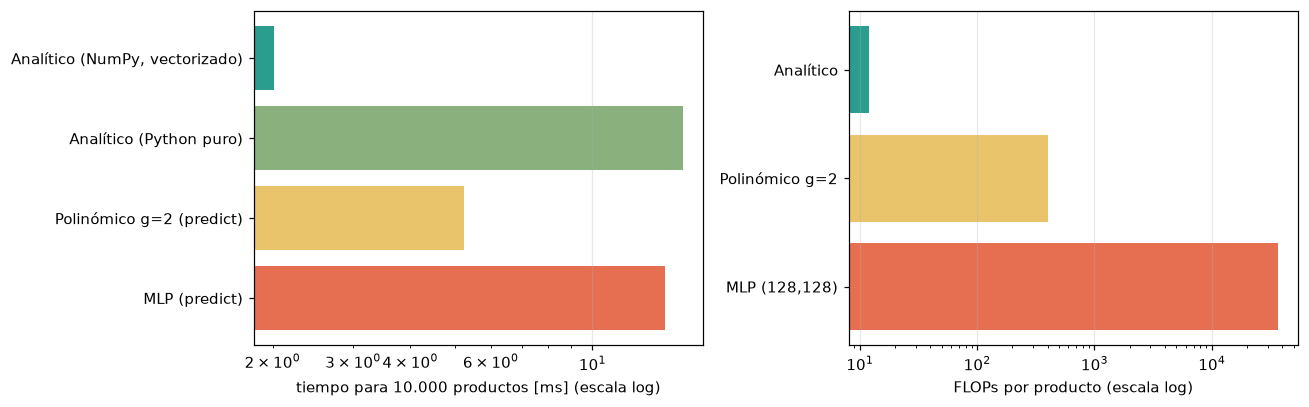

In [34]:
# ============================================================
# 1.7 Medición empírica del tiempo (10.000 productos)
# ============================================================
M = 10_000
Xt = X1_te[:M]; At = Xt[:, :4].reshape(M, 2, 2); Bt = Xt[:, 4:].reshape(M, 2, 2)

def cronometrar(f, rep=5):
    ts = []
    for _ in range(rep):
        t0 = time.perf_counter(); f(); ts.append(time.perf_counter() - t0)
    return min(ts)

def python_puro():
    for a, b in zip(At.tolist(), Bt.tolist()):
        [[a[0][0]*b[0][0]+a[0][1]*b[1][0], a[0][0]*b[0][1]+a[0][1]*b[1][1]],
         [a[1][0]*b[0][0]+a[1][1]*b[1][0], a[1][0]*b[0][1]+a[1][1]*b[1][1]]]

tiempos = {
    'Analítico (NumPy, vectorizado)': cronometrar(lambda: At @ Bt),
    'Analítico (Python puro)':        cronometrar(python_puro),
    'Polinómico g=2 (predict)':       cronometrar(lambda: modelos_mat['Polinómico g=2'].predict(Xt)),
    'MLP (predict)':                  cronometrar(lambda: modelos_mat['MLP (128,128)'].predict(Xt)),
}
t_ref = tiempos['Analítico (NumPy, vectorizado)']
for k, v in tiempos.items():
    print(f"{k:32s}: {v*1e3:9.3f} ms   ({v/t_ref:8.1f}x el analítico vectorizado)")

fig, ax = plt.subplots(1, 2, figsize=(12, 3.8))
ax[0].barh(list(tiempos), [v*1e3 for v in tiempos.values()], color=['#2a9d8f', '#8ab17d', '#e9c46a', '#e76f51'])
ax[0].set_xscale('log'); ax[0].set_xlabel('tiempo para 10.000 productos [ms] (escala log)'); ax[0].invert_yaxis()
ax[1].barh(list(flops), list(flops.values()), color=['#2a9d8f', '#e9c46a', '#e76f51'])
ax[1].set_xscale('log'); ax[1].set_xlabel('FLOPs por producto (escala log)'); ax[1].invert_yaxis()
for a in ax: a.grid(axis='y', alpha=0)
plt.tight_layout(); plt.show()

## 1.8 Conclusiones del ejercicio 1

1. **La regresión lineal falla por completo** ($R^2 \approx 0$), como se predijo: la multiplicación no tiene ninguna componente lineal.
2. **La regresión polinómica de grado 2 acierta el 100 % de los casos**, también en extrapolación, porque su espacio de hipótesis contiene la regla verdadera. Los coeficientes que aprendió *son* la fórmula de $AB$.
3. **La MLP tiene $R^2 \approx 0.997$, pero no acierta exactamente ninguno de los 10 ejemplos.** Su MAE por ejemplo está entre ≈3 y ≈17 unidades, con errores de hasta ≈35. Fuera del rango de entrenamiento colapsa (MAE de miles), porque una red ReLU extrapola de forma lineal. Un $R^2$ alto no garantiza que el modelo haya aprendido la regla.
4. **Costo:** en operaciones, el método analítico es órdenes de magnitud más barato. Usa 12 FLOPs, frente a ≈400 del modelo polinómico (≈33×) y ≈36.000 de la MLP (≈3.000×), sin contar el entrenamiento: ≈1,6·10⁸ FLOPs para el polinómico y ≈1,8·10¹¹ para la MLP. En tiempo real medido la diferencia es menor (≈10× y ≈45× frente a NumPy vectorizado), porque con matrices tan pequeñas domina el *overhead* de Python y de scikit-learn, no la aritmética. Además, para construir el dataset de ML hubo que hacer antes las 50.000 multiplicaciones analíticamente.

**Lección:** ML conviene cuando **no se conoce la regla** o cuando es muy costoso programarla, como en la traducción automática o en el filtro de spam de la sección 6.2. Cuando la regla es conocida, exacta y barata, como en la aritmética, el enfoque de la programación tradicional de la figura 6.1 es superior en exactitud y en costo.

---
# 2. Base común para los ejercicios 3 y 4: Pong + Q-Learning corregido

Los dos notebooks de clase siguen el mismo flujo:

1. entrenar un agente de **Q-Learning** en Pong;
2. convertir la Q-table en un dataset supervisado `(estado → mejor acción)`;
3. entrenar un clasificador (K-NN o árbol) que **imite la política**.

Antes de cambiar el clasificador revisé el entorno, porque un clasificador no puede ser mejor que los datos que recibe.

## 2.1 Diagnóstico del código original

| # | Problema en el código original | Consecuencia |
|---|---|---|
| 1 | **Índices negativos.** El estado se calcula como `floor(pos/3) - 2`. La raqueta llega a `player1 = -3` y la pelota a `y < 0`, lo que da índices de −3 a −1. | NumPy interpreta un índice negativo como “contar desde el final”: el agente **lee y escribe la celda de otro estado** sin ningún error. |
| 2 | **El estado no incluye la dirección de la pelota** (`dx`, `dy`). | Una pelota que se acerca y una que se aleja son el *mismo* estado, aunque la acción óptima sea distinta. El estado no es **markoviano**, que es el supuesto central de Q-Learning. |
| 3 | `reset()` devuelve `[0,0,0]` en lugar del estado real. | La primera transición de cada episodio se registra en un estado ficticio. |
| 4 | Sin límite de pasos (notebook de árboles). | Si el agente aprende a no perder, el episodio **nunca termina** y `play()` queda en un ciclo infinito. |
| 5 | El dataset incluye **todos** los estados de la Q-table, también los nunca visitados, cuyo Q es `[0, 0]`. | En esos estados `argmax` devuelve 0 (“Arriba”) por defecto: son **etiquetas basura**. Muchos otros estados tienen $Q_0 \approx Q_1$, es decir, la acción es indiferente. |
| 6 | La única métrica es la *accuracy* contra la Q-table. | No mide lo que importa: **¿el clasificador juega bien?** |
| 7 | Los textos de interpretación no coinciden con las salidas. | El árbol dice 66,3 % y el output muestra 64,8 %; el K-NN dice 65,8 % y el output muestra 68,4 %. |

La siguiente celda cuantifica el problema 1. Simula la física del juego, que es idéntica a la original, y aplica la **fórmula de estado original** a las posiciones que se presentan realmente.

In [9]:
# ============================================================
# 2.1 Evidencia del bug de índices negativos (fórmula original del estado)
# ============================================================
def estado_original(player1, y, x, m=3):
    return (floor(player1/m) - 2, floor(y/m) - 2, floor(x/m) - 2)

rng_d = random.Random(0)
H, W, m, alto = 40, 50, 3, 10
neg, total = 0, 0
p1, x, y, dx, dy = alto, 40, 20, m, m
for t in range(200_000):                      # raqueta con movimiento aleatorio (exploración)
    p1 += m if rng_d.random() < .5 else -m
    p1 = min(max(p1, -m), H - alto)
    x += dx; y += dy
    if x <= 3 or x > W: dx = -dx
    if y < 0 or y > H: dy = -dy
    s = estado_original(p1, y, x)
    neg += any(v < 0 for v in s); total += 1
print(f"Pasos con algún índice NEGATIVO: {100*neg/total:.1f} %")
print(f"Rango de índices con la fórmula original -> player: [{floor(-3/3)-2}, {floor(30/3)-2}],  "
      f"ball_y: [{floor(-3/3)-2}, {floor(43/3)-2}],  ball_x: [{floor(0/3)-2}, {floor(53/3)-2}]")

Pasos con algún índice NEGATIVO: 43.6 %
Rango de índices con la fórmula original -> player: [-3, 8],  ball_y: [-3, 12],  ball_x: [-2, 15]


## 2.2 Entorno y agente corregidos

Cambios respecto al original. La física del juego, las recompensas (+10 por golpe, −10 por punto perdido) y los hiperparámetros de Q-Learning ($\gamma=0.1$, $\alpha=0.1$, explotación 0.9) **se mantienen**:

* **Discretización segura:** `bin = clip(floor(pos/m) + 1, 0, n-1)`, con una tabla dimensionada a partir de los rangos reales.
* **Estado markoviano (opcional):** `(raqueta, pelota_y, pelota_x, dir_x, dir_y)`. El parámetro `usar_direccion` permite comparar con el estado original de 3 variables.
* `reset()` devuelve el estado real, hay un límite `max_steps` y se cuentan los golpes (`hits`) para evaluar.
* El agente lleva un **contador de visitas** por estado, que sirve para construir un dataset limpio.
* La aleatoriedad es reproducible (`seed`), y en la toma de decisiones se usa `random` en vez de `np.random`, porque es unas 10 veces más rápido para escalares.

In [35]:
# ============================================================
# 2.2 Entorno Pong corregido
# ============================================================
class PongEnvironment:
    """Pong de un jugador (raqueta a la izquierda) sobre una grilla de 40x50 px.

    Estado discreto: (raqueta, pelota_y, pelota_x[, dir_x, dir_y]).
      - posiciones discretizadas en celdas de `movimiento_px` px, con índice siempre válido (>= 0);
      - dir_x = 1 si la pelota se aleja de la raqueta (dx > 0), 0 si se acerca;
      - dir_y = 1 si la pelota sube (dy > 0), 0 si baja.
    Recompensas: +10 al golpear la pelota, -10 al dejarla pasar (se pierde una vida), 0 en los demás pasos.
    """
    ACTIONS = ['Arriba', 'Abajo']

    def __init__(self, max_life=3, height_px=40, width_px=50, movimiento_px=3,
                 usar_direccion=True, max_steps=2000, seed=None):
        self.rng = random.Random(seed)
        self.action_space = list(self.ACTIONS)
        self.height_px, self.width_px, self.m = height_px, width_px, movimiento_px
        self.max_life, self.max_steps = max_life, max_steps
        self.player_alto = int(height_px / 4)
        self.radio = 2.5
        self.usar_direccion = usar_direccion
        n_y = ceil(height_px / movimiento_px) + 2      # +2: margen para posiciones -m y > height
        n_x = ceil(width_px / movimiento_px) + 2
        self.state_shape = (n_y, n_y, n_x) + ((2, 2) if usar_direccion else ())
        self.reset()

    # ---------- utilidades ----------
    def _lanzar(self):
        self.x = self.rng.randint(self.width_px // 2, self.width_px)
        self.y = self.rng.randint(0, self.height_px - 10)
        self.dx, self.dy = self.m, self.m

    def _bin(self, v, n):
        return min(max(floor(v / self.m) + 1, 0), n - 1)     # índice SIEMPRE en [0, n-1]

    def _estado(self):
        s = (self._bin(self.player1, self.state_shape[0]),
             self._bin(self.y, self.state_shape[1]),
             self._bin(self.x, self.state_shape[2]))
        if self.usar_direccion:
            s += (int(self.dx > 0), int(self.dy > 0))
        return s

    # ---------- API tipo gym ----------
    def reset(self):
        self.lives, self.total_reward, self.hits, self.steps, self.score = self.max_life, 0, 0, 0, 0
        self.player1 = self.player_alto
        self._lanzar()
        self.state = self._estado()
        return self.state

    def step(self, action):
        self.player1 += self.m if action == 'Arriba' else -self.m
        self.player1 = min(max(self.player1, -self.m), self.height_px - self.player_alto)
        self._avanza_frame()
        self.steps += 1
        self.state = self._estado()
        self.total_reward += self.score
        done = self.lives <= 0 or self.steps >= self.max_steps
        return self.state, self.score, done

    # ---------- física (idéntica al original) ----------
    def _colision(self):
        return (self.player1 + self.player_alto >= self.y - self.radio) and (self.player1 <= self.y + self.radio)

    def _avanza_frame(self):
        self.score = 0
        self.x += self.dx; self.y += self.dy
        if self.x <= 3 or self.x > self.width_px:
            self.dx = -self.dx
            if self.x <= 3:
                if self._colision():
                    self.score = 10; self.hits += 1
                else:
                    self.score = -10; self.lives -= 1
                    if self.lives > 0:
                        self._lanzar()
        if self.y < 0 or self.y > self.height_px:
            self.dy = -self.dy


class PongAgent:
    """Agente Q-Learning tabular con política epsilon-greedy.

    Q(s,a) <- Q(s,a) + alpha * [ r + gamma * max_a' Q(s',a') - Q(s,a) ]   (ecuación de Bellman)
    """
    def __init__(self, game, discount_factor=0.1, learning_rate=0.1, ratio_explotacion=0.9, seed=None):
        self.rng = random.Random(seed)
        self.actions = game.action_space
        self.q = np.zeros(game.state_shape + (len(self.actions),))
        self.visitas = np.zeros(game.state_shape, dtype=int)
        self.gamma, self.alpha, self.explot = discount_factor, learning_rate, ratio_explotacion

    def get_next_step(self, s):
        if self.rng.random() <= self.explot:                 # explotar
            q0, q1 = self.q[s]
            if q0 != q1:
                return self.actions[0] if q0 > q1 else self.actions[1]
        return self.actions[self.rng.randrange(2)]           # explorar (o desempate aleatorio)

    def update(self, s, a, r, s2, terminal):
        i = self.actions.index(a)
        objetivo = r if terminal else r + self.gamma * self.q[s2].max()
        self.q[s + (i,)] += self.alpha * (objetivo - self.q[s + (i,)])
        self.visitas[s] += 1

    def accion_greedy(self, s):
        return self.actions[int(np.argmax(self.q[s]))]


def entrenar(rounds=3000, seed=0, usar_direccion=True, **agent_kwargs):
    game = PongEnvironment(seed=seed, usar_direccion=usar_direccion)
    agente = PongAgent(game, seed=seed, **agent_kwargs)
    for _ in range(rounds):
        s, done = game.reset(), False
        while not done:
            a = agente.get_next_step(s)
            s2, r, done = game.step(a)
            agente.update(s, a, r, s2, terminal=game.lives <= 0)
            s = s2
    return agente, game


def evaluar(politica, n_episodios=100, seed=123, usar_direccion=True):
    """Juega n episodios con una política (función estado -> acción) SIN exploración.
    Episodio = 3 vidas o 2000 pasos. En 2000 pasos caben como máximo ~60 golpes."""
    game = PongEnvironment(seed=seed, usar_direccion=usar_direccion)
    golpes, perdidas = [], []
    for _ in range(n_episodios):
        s, done = game.reset(), False
        while not done:
            s, _, done = game.step(politica(s))
        golpes.append(game.hits); perdidas.append(game.max_life - game.lives)
    return {'golpes/episodio': np.mean(golpes), 'vidas perdidas/episodio': np.mean(perdidas),
            'golpes por vida perdida': np.sum(golpes) / max(np.sum(perdidas), 1)}

## 2.3 ¿Qué tanto mejora el agente al usar un estado markoviano?

Se entrenan agentes con el estado original de 3 variables y con el estado de 5 variables, que incluye la dirección. Para cada configuración se usan 3 semillas y 3.000 episodios, con los mismos hiperparámetros del notebook de clase. Como referencia se incluyen una política **aleatoria** y una **heurística** escrita a mano (“mover la raqueta hacia la pelota”).

In [36]:
# ============================================================
# 2.3 Entrenamiento: estado original (3 vars) vs estado markoviano (5 vars)
# ============================================================
filas, agentes = [], {}
for usar_dir in [False, True]:
    for seed in [0, 1, 2]:
        t0 = time.perf_counter()
        ag, _ = entrenar(rounds=3000, seed=seed, usar_direccion=usar_dir)
        t_tr = time.perf_counter() - t0
        agentes[(usar_dir, seed)] = ag
        r = evaluar(ag.accion_greedy, usar_direccion=usar_dir)
        filas.append({'estado': '5 vars (con dirección)' if usar_dir else '3 vars (original)', 'seed': seed,
                      **r, 't_entrenamiento [s]': t_tr})

rng_pol = random.Random(1)
filas.append({'estado': 'Política aleatoria', 'seed': '-', **evaluar(lambda s: rng_pol.choice(['Arriba', 'Abajo']), usar_direccion=False)})
filas.append({'estado': 'Heurística "seguir la pelota"', 'seed': '-',
              **evaluar(lambda s: 'Arriba' if s[1] > s[0] + 1 else 'Abajo', usar_direccion=False)})
res_q = pd.DataFrame(filas)
print(res_q.round(2).to_string(index=False))
print('\nPromedio por tipo de estado:')
print(res_q.groupby('estado', sort=False)[['golpes/episodio', 'vidas perdidas/episodio']].mean().round(2).to_string())

                       estado seed  golpes/episodio  vidas perdidas/episodio  golpes por vida perdida  t_entrenamiento [s]
            3 vars (original)    0            44.05                     1.62                    27.19                 7.33
            3 vars (original)    1            20.97                     2.63                     7.97                 6.68
            3 vars (original)    2            15.53                     3.00                     5.18                 6.54
       5 vars (con dirección)    0            59.82                     0.21                   284.86                22.82
       5 vars (con dirección)    1            58.86                     0.45                   130.80                21.29
       5 vars (con dirección)    2            59.82                     0.21                   284.86                25.26
           Política aleatoria    -             1.69                     3.00                     0.56                  NaN
Heurística "segu

**Interpretación.** Con el estado original, el agente tiene un desempeño mediocre y **muy variable entre semillas**: confunde una pelota que se acerca con una que se aleja. Con el estado markoviano, los 3 agentes **juegan casi tan bien como la heurística**, que en este entorno es prácticamente óptima: unos 60 golpes en 2.000 pasos, que es el máximo posible, porque la pelota tarda unos 34 *frames* en ir y volver. La heurística también pierde ≈0,2 vidas por episodio, lo que sugiere que esas pérdidas vienen de lanzamientos imposibles de alcanzar más que de errores del agente.

Este es el **cambio de mayor impacto** de todo el trabajo, y no tiene que ver con el clasificador: es la **representación del estado** (*feature engineering* en el problema de RL).

## 2.4 Dataset supervisado limpio

Se usa el agente de 5 variables con `seed=0`. Se comparan dos formas de construir el dataset:

* **Original:** todos los estados de la tabla, con `argmax(Q)` como etiqueta.
* **Limpio:** solo los estados **visitados** en los que la acción **importa** ($|Q_{Abajo} - Q_{Arriba}| > 0.01$). Los estados donde las dos acciones dan el mismo resultado no enseñan nada al clasificador, así que se descartan.

*Features* del clasificador: las 5 variables del estado más una variable derivada, **`dif_y = pelota_y − raqueta`**, la posición relativa de la pelota respecto a la raqueta. Tanto el K-NN como el árbol se benefician de ella. Al K-NN le define una distancia más relevante, y al árbol le permite expresar con **un solo corte** una frontera que con las variables originales es diagonal.

In [37]:
# ============================================================
# 2.4 Construcción de los datasets supervisados
# ============================================================
agente = agentes[(True, 0)]
Q, V = agente.q, agente.visitas
dQ = Q[..., 1] - Q[..., 0]
FEATS = ['raqueta', 'pelota_y', 'pelota_x', 'dir_x', 'dir_y', 'dif_y']

def features_pong(estados):
    S = np.asarray(estados, dtype=float).reshape(-1, 5)
    return np.c_[S, S[:, 1] - S[:, 0]]

# (a) dataset "original": todos los estados de la tabla
idx_all = np.argwhere(np.ones(Q.shape[:-1], bool))
y_all = np.argmax(Q[tuple(idx_all.T)], axis=1)
# (b) dataset limpio: estados visitados y "decisivos"
mask = (V > 0) & (np.abs(dQ) > 0.01)
idx_dec = np.argwhere(mask)
X_pong = features_pong(idx_dec)
y_pong = (dQ[tuple(idx_dec.T)] > 0).astype(int)          # 1 = 'Abajo', 0 = 'Arriba'

print(f"Estados totales de la tabla     : {Q[...,0].size:6d}")
print(f"  nunca visitados (Q = [0,0])   : {(V == 0).sum():6d}  ({100*(V == 0).mean():.1f} %) -> etiqueta 'Arriba' por defecto")
print(f"  visitados                     : {(V > 0).sum():6d}")
print(f"  visitados y decisivos         : {len(X_pong):6d}  <- dataset limpio")
print(f"Balance de clases (limpio): Arriba = {np.mean(y_pong == 0):.2f}, Abajo = {np.mean(y_pong == 1):.2f}")

def tabla_de_politica(modelo):
    """'Compila' un clasificador a una tabla: predice TODOS los estados una sola vez.
    Así se puede jugar sin llamar a .predict() en cada frame (que sería ~1000 veces más lento)."""
    pred = modelo.predict(features_pong(idx_all)).reshape(Q.shape[:-1])
    return lambda s: 'Abajo' if pred[s] == 1 else 'Arriba'

ref_q = evaluar(agente.accion_greedy)
print('\nAgente Q-Learning (maestro):', {k: round(v, 2) for k, v in ref_q.items()})

Estados totales de la tabla     :  19456
  nunca visitados (Q = [0,0])   :   8366  (43.0 %) -> etiqueta 'Arriba' por defecto
  visitados                     :  11090
  visitados y decisivos         :    955  <- dataset limpio
Balance de clases (limpio): Arriba = 0.49, Abajo = 0.51

Agente Q-Learning (maestro): {'golpes/episodio': np.float64(59.82), 'vidas perdidas/episodio': np.float64(0.21), 'golpes por vida perdida': np.float64(284.86)}


---
# 3. Ejercicio 3 — K-Nearest Neighbors (K-NN)

> *Estudie el algoritmo de K-Nearest con todo detalle, mejore su documentación y con base en él haga cambios para una aplicación.*

## 3.1 El algoritmo en detalle

**Idea:** “dime con quién andas y te diré quién eres”. K-NN es un método **no paramétrico** y **perezoso** (*lazy learning*): no ajusta parámetros durante el entrenamiento, solo **almacena** los datos. Todo el trabajo se hace al predecir.

**Algoritmo de clasificación.** Dado un conjunto $\{(x_i, y_i)\}_{i=1}^n$ y un punto nuevo $x$:

1. calcular la distancia $d(x, x_i)$ a todos los puntos de entrenamiento;
2. tomar el conjunto $N_k(x)$ de los $k$ puntos más cercanos;
3. predecir por **voto mayoritario**: $\hat y = \arg\max_c \sum_{i\in N_k(x)} w_i\,\mathbb 1[y_i = c]$, con $w_i = 1$ (voto uniforme) o $w_i = 1/d(x, x_i)$ (voto ponderado por distancia).

En regresión, el voto se reemplaza por el promedio (ponderado) de los $y_i$.

**Métricas de distancia (familia de Minkowski):** $d_p(x,z) = \left(\sum_j |x_j - z_j|^p\right)^{1/p}$

| $p$ | Nombre | Comentario |
|---|---|---|
| 1 | Manhattan | Más robusta a valores atípicos en una sola dimensión; adecuada para grillas discretas como la de Pong |
| 2 | Euclidiana | El valor por defecto de scikit-learn |
| ∞ | Chebyshev | Solo cuenta la diferencia más grande |

Para variables categóricas se usa Hamming, o se codifican primero (*one-hot* u ordinal).

**Elección de $k$ (*bias–variance trade-off*):**

* $k = 1$: frontera muy irregular, **varianza alta** y riesgo de *overfitting*; la exactitud en entrenamiento es siempre 100 %.
* $k$ grande: frontera suave, **sesgo alto** y riesgo de *underfitting*. Con $k = n$ el modelo predice siempre la clase mayoritaria.
* $k$ se elige con **validación cruzada**. En problemas binarios conviene un $k$ impar para evitar empates.

**Escalado:** como la distancia mezcla variables, una variable con rango [0, 1000] domina sobre una con rango [0, 1]. Por eso casi siempre hace falta `StandardScaler` o `MinMaxScaler`.

**Maldición de la dimensionalidad:** en espacios de muchas dimensiones, las distancias entre puntos tienden a parecerse, y “el más cercano” deja de ser informativo. Conviene usar pocas *features* y que sean relevantes.

**Costo computacional:**

| Fase | Fuerza bruta | Con KD-tree / Ball-tree |
|---|---|---|
| Entrenamiento | $O(1)$ (solo copia los datos) | $O(n \log n)$ para construir el árbol |
| Predicción de 1 punto | $O(n\,d)$ | $\approx O(\log n)$ en dimensión baja |
| Memoria | $O(n\,d)$ | $O(n\,d)$ |

**Ventajas:** es simple, no supone ninguna forma para la frontera, admite multiclase de forma natural y se actualiza con solo agregar datos.
**Desventajas:** la predicción es lenta con $n$ grande, es sensible a la escala y a *features* irrelevantes, y no produce un modelo interpretable.

## 3.2 Implementación desde cero

Para entender el algoritmo “con todo detalle”, se implementa en NumPy y se comprueba que da exactamente las mismas predicciones que `sklearn`.

In [38]:
# ============================================================
# 3.2 K-NN desde cero (vectorizado con NumPy)
# ============================================================
class KNNDesdeCero:
    """Clasificador K-NN. p=1 Manhattan, p=2 Euclidiana. weights='uniform' | 'distance'."""
    def __init__(self, k=5, p=2, weights='uniform'):
        self.k, self.p, self.weights = k, p, weights

    def fit(self, X, y):                         # "entrenar" = memorizar
        self.X_, self.y_ = np.asarray(X, float), np.asarray(y)
        self.clases_ = np.unique(self.y_)
        return self

    def _distancias(self, X):
        dif = np.abs(X[:, None, :] - self.X_[None, :, :])          # (n_test, n_train, d)
        return (dif ** self.p).sum(axis=2) ** (1 / self.p)

    def predict(self, X):
        D = self._distancias(np.asarray(X, float))
        vecinos = np.argsort(D, axis=1, kind='stable')[:, :self.k]  # índices de los k más cercanos
        dk = np.take_along_axis(D, vecinos, axis=1)
        w = np.ones_like(dk) if self.weights == 'uniform' else 1 / np.maximum(dk, 1e-12)
        votos = np.stack([(w * (self.y_[vecinos] == c)).sum(axis=1) for c in self.clases_], axis=1)
        return self.clases_[np.argmax(votos, axis=1)]

# Verificación contra scikit-learn en el dataset limpio de Pong
Xa, Xb, ya, yb = train_test_split(X_pong, y_pong, test_size=0.3, random_state=SEED, stratify=y_pong)
for k, p, w in [(1, 2, 'uniform'), (5, 1, 'uniform'), (7, 2, 'distance')]:
    mio = KNNDesdeCero(k, p, w).fit(Xa, ya).predict(Xb)
    skl = KNeighborsClassifier(n_neighbors=k, p=p, weights=w, algorithm='brute').fit(Xa, ya).predict(Xb)
    print(f"k={k}, p={p}, weights={w:8s}: coincidencia con sklearn = {100*np.mean(mio == skl):.1f} %   "
          f"accuracy = {accuracy_score(yb, mio):.3f}")

k=1, p=2, weights=uniform : coincidencia con sklearn = 100.0 %   accuracy = 0.627
k=5, p=1, weights=uniform : coincidencia con sklearn = 99.3 %   accuracy = 0.693
k=7, p=2, weights=distance: coincidencia con sklearn = 95.8 %   accuracy = 0.693


Una diferencia mínima con `sklearn` puede aparecer cuando hay **empates en distancia**: en una grilla de enteros es común que varios vecinos estén exactamente a la misma distancia, y cada implementación desempata a su manera. Esto ilustra una sutileza real de K-NN con datos discretos.

## 3.3 Aplicación a Pong: ajuste de hiperparámetros

Con `GridSearchCV` (5 *folds* estratificados) se buscan $k$, el peso de los votos, la métrica ($p$) y si conviene escalar las *features*, y se compara el conjunto de *features* original con el que incluye `dif_y`.

In [39]:
# ============================================================
# 3.3 GridSearch de K-NN en Pong
# ============================================================
cv5 = StratifiedKFold(5, shuffle=True, random_state=SEED)
pipe_knn = Pipeline([('esc', StandardScaler()), ('knn', KNeighborsClassifier())])
grid_knn = {'esc': [StandardScaler(), 'passthrough'],
            'knn__n_neighbors': [1, 3, 5, 7, 9, 15, 25, 41],
            'knn__weights': ['uniform', 'distance'],
            'knn__p': [1, 2]}
resultados_knn = {}
for nombre, cols in [('5 features (estado)', slice(0, 5)), ('6 features (+ dif_y)', slice(0, 6))]:
    gs = GridSearchCV(pipe_knn, grid_knn, cv=cv5, scoring='accuracy', n_jobs=-1).fit(X_pong[:, cols], y_pong)
    resultados_knn[nombre] = gs
    print(f"{nombre:22s} mejor CV accuracy = {gs.best_score_:.3f}  con {gs.best_params_}")

# Exactitud con el dataset ORIGINAL (todos los estados, incluidas etiquetas basura), para comparar
acc_orig = cross_val_score(KNeighborsClassifier(5), features_pong(idx_all), y_all, cv=cv5).mean()
print(f"\nEnfoque original (todos los estados, k=5): CV accuracy = {acc_orig:.3f}")

5 features (estado)    mejor CV accuracy = 0.676  con {'esc': StandardScaler(), 'knn__n_neighbors': 9, 'knn__p': 2, 'knn__weights': 'distance'}
6 features (+ dif_y)   mejor CV accuracy = 0.688  con {'esc': StandardScaler(), 'knn__n_neighbors': 41, 'knn__p': 2, 'knn__weights': 'distance'}

Enfoque original (todos los estados, k=5): CV accuracy = 0.768


**Resultado paradójico, y muy instructivo:** el enfoque de clase obtiene **mayor *accuracy*** (≈0,77) que el dataset limpio (≈0,69). Se explica porque el 43 % de sus ejemplos son estados nunca visitados, todos etiquetados “Arriba” y agrupados en zonas del espacio a las que el agente nunca llega. Son ejemplos **fáciles de acertar e inútiles para jugar**. La sección 3.4 muestra lo que pasa al usar ese modelo en el juego.

En el dataset limpio, *accuracy* ≈0,69 es razonable: muchos estados decisivos tienen $|\Delta Q|$ muy pequeño, de modo que la etiqueta es casi una moneda al aire. Agregar `dif_y` sube la *accuracy* en ≈1 punto, y el mejor $k$ es grande ($k=41$, con votos ponderados por distancia).

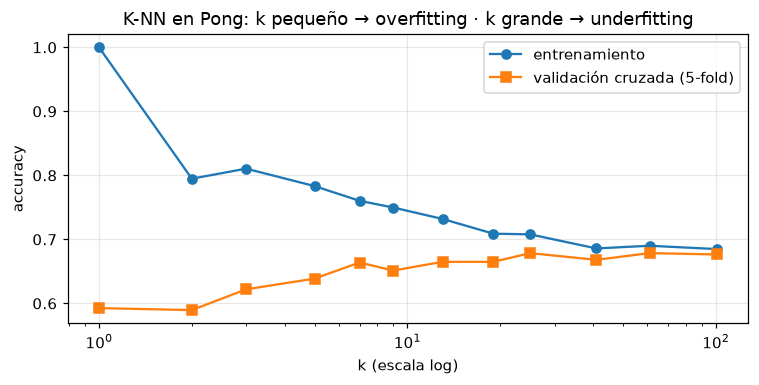

k con mejor CV: 61 (accuracy = 0.679)


In [40]:
# ============================================================
# Curva de validación: efecto de k (bias-variance)
# ============================================================
ks = [1, 2, 3, 5, 7, 9, 13, 19, 25, 41, 61, 101]
tr_acc, cv_acc = [], []
for k in ks:
    m = KNeighborsClassifier(n_neighbors=k, p=1)
    cv_acc.append(cross_val_score(m, X_pong, y_pong, cv=cv5).mean())
    tr_acc.append(m.fit(X_pong, y_pong).score(X_pong, y_pong))
plt.figure(figsize=(7, 3.6))
plt.plot(ks, tr_acc, 'o-', label='entrenamiento'); plt.plot(ks, cv_acc, 's-', label='validación cruzada (5-fold)')
plt.xscale('log'); plt.xlabel('k (escala log)'); plt.ylabel('accuracy'); plt.legend()
plt.title('K-NN en Pong: k pequeño → overfitting · k grande → underfitting'); plt.tight_layout(); plt.show()
print('k con mejor CV:', ks[int(np.argmax(cv_acc))], f'(accuracy = {max(cv_acc):.3f})')

## 3.4 La prueba que importa: ¿el K-NN **juega** bien?

Una *accuracy* moderada contra la Q-table no implica necesariamente un mal desempeño, porque muchas etiquetas corresponden a estados donde equivocarse cuesta poco. Por eso cada modelo se evalúa **jugando 100 episodios** y se grafica su **frontera de decisión** sobre el plano (raqueta, pelota_y), con la pelota acercándose.

                                             golpes/episodio  vidas perdidas/episodio  golpes por vida perdida
política                                                                                                      
Q-Learning (maestro)                                   59.82                     0.21                   284.86
K-NN mejor (GridSearch)                                59.82                     0.21                   284.86
K-NN k=1                                                8.39                     3.00                     2.80
K-NN como en clase (todos los estados, k=5)            12.28                     2.90                     4.23


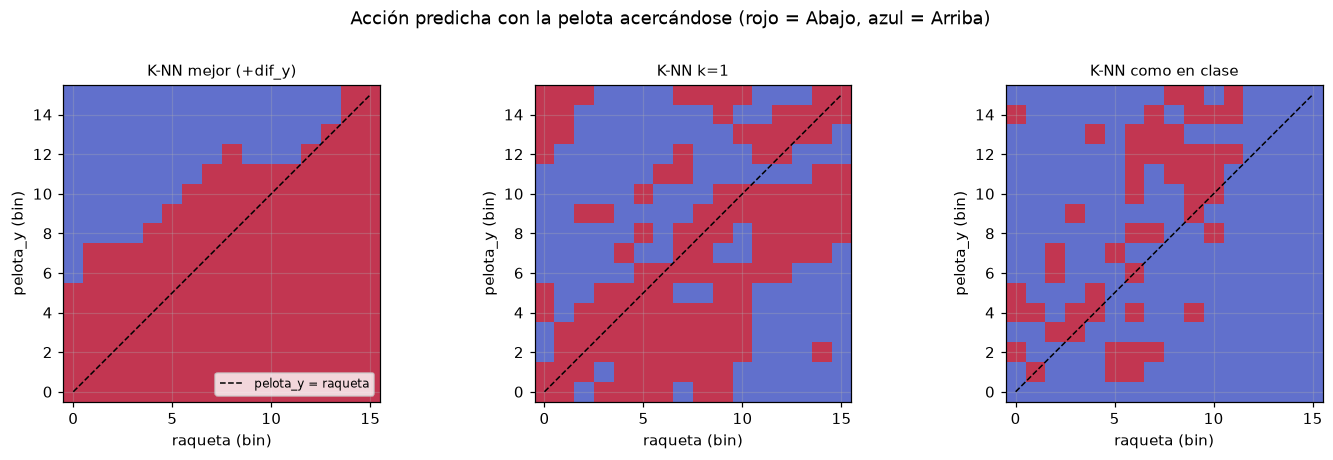

In [41]:
# ============================================================
# 3.4 Evaluación jugando + frontera de decisión
# ============================================================
knn_best = resultados_knn['6 features (+ dif_y)'].best_estimator_
knn_k1   = KNeighborsClassifier(n_neighbors=1).fit(X_pong, y_pong)
knn_orig = KNeighborsClassifier(n_neighbors=5).fit(features_pong(idx_all), y_all)   # como en clase

filas = [{'política': 'Q-Learning (maestro)', **ref_q},
         {'política': 'K-NN mejor (GridSearch)', **evaluar(tabla_de_politica(knn_best))},
         {'política': 'K-NN k=1', **evaluar(tabla_de_politica(knn_k1))},
         {'política': 'K-NN como en clase (todos los estados, k=5)', **evaluar(tabla_de_politica(knn_orig))}]
res_knn_juego = pd.DataFrame(filas).set_index('política')
print(res_knn_juego.round(2).to_string())

def plot_frontera(modelo, ax, titulo, pelota_x=8, dir_x=0, dir_y=0):
    n = Q.shape[0]
    R, Y = np.meshgrid(np.arange(n), np.arange(n))
    est = np.c_[R.ravel(), Y.ravel(), np.full(R.size, pelota_x), np.full(R.size, dir_x), np.full(R.size, dir_y)]
    Z = modelo.predict(features_pong(est)).reshape(R.shape)
    ax.imshow(Z, origin='lower', cmap='coolwarm', alpha=.8, vmin=0, vmax=1)
    ax.plot([0, n-1], [0, n-1], 'k--', lw=1, label='pelota_y = raqueta')
    ax.set_xlabel('raqueta (bin)'); ax.set_ylabel('pelota_y (bin)'); ax.set_title(titulo, fontsize=10)

fig, axs = plt.subplots(1, 3, figsize=(13, 4))
plot_frontera(knn_best, axs[0], 'K-NN mejor (+dif_y)')
plot_frontera(knn_k1, axs[1], 'K-NN k=1')
plot_frontera(knn_orig, axs[2], 'K-NN como en clase')
axs[0].legend(loc='lower right', fontsize=8)
fig.suptitle('Acción predicha con la pelota acercándose (rojo = Abajo, azul = Arriba)', y=1.02)
plt.tight_layout(); plt.show()

**Lectura de resultados:**

* La política ideal es “subir si la pelota está por encima de la raqueta y bajar si está por debajo”; la acción “Arriba” *aumenta* la posición de la raqueta. En el plano (raqueta, pelota_y) eso da una **frontera diagonal**, desplazada ≈1,5 *bins* sobre la línea punteada porque `raqueta` es el borde inferior de una paleta de 10 px (≈3 *bins*) de alto.
* **K-NN mejor** ($k=41$, ponderado): frontera diagonal limpia. **Juega igual que el maestro** (≈60 golpes y 0,21 vidas perdidas por episodio).
* **K-NN con $k=1$:** frontera fragmentada. Memoriza el ruido de las etiquetas, y en el juego cae a ≈8 golpes por episodio. Es el *overfitting* de la curva anterior, visto en el juego.
* **K-NN como en clase:** casi todo el plano queda en “Arriba”, porque los vecinos de un estado real suelen ser estados nunca visitados con etiqueta basura. Pese a su mayor *accuracy*, juega muy mal (≈12 golpes por episodio).

**Conclusión:** para K-NN, la limpieza del dataset y la elección de $k$ son decisivas, y la *accuracy* sola habría llevado a escoger el modelo equivocado.

## 3.5 Aplicación con datos gubernamentales: Saber 11 (ICFES, datos.gov.co)

**Pregunta:** ¿qué tan bien pueden predecir las **condiciones socioeconómicas del hogar y las características del colegio** si un estudiante queda por encima de la **mediana del puntaje global** de Saber 11?

* **Fuente:** ICFES, *Resultados únicos Saber 11*, portal de Datos Abiertos de Colombia (`https://www.datos.gov.co/resource/kgxf-xxbe`), periodo **2019-2**, que es el último antes de la pandemia.
* **Muestra:** estudiantes cuyo consecutivo termina en “7”, lo que equivale a una muestra pseudoaleatoria de ~10 % (≈ 50.000 registros). La descarga se guarda en un archivo CSV local para no repetirla.
* **Objetivo binario:** `alto = 1` si `punt_global` ≥ mediana de la muestra. La clase queda balanceada por construcción.
* ***Features*** (ninguna es un puntaje): estrato, educación de la madre y del padre, número de cuartos y de personas del hogar, si tiene internet, computador, automóvil o lavadora, y del colegio: si es oficial, rural o bilingüe, su jornada, calendario, carácter y género. El **género del estudiante no se usa como *feature***; se usa solo para auditar el modelo en la sección 5.

> **Nota:** esta parte requiere internet. Si la API falla, se puede descargar el CSV manualmente desde datos.gov.co, guardarlo como `saber11_20194.csv` y volver a ejecutar.

In [42]:
# ============================================================
# 3.5.a Descarga de datos del ICFES vía API Socrata (datos.gov.co)
# ============================================================
import requests

URL_SABER11 = "https://www.datos.gov.co/resource/kgxf-xxbe.csv"
CAMPOS = ['periodo', 'estu_consecutivo', 'estu_genero', 'fami_estratovivienda', 'fami_educacionmadre', 'fami_educacionpadre',
          'fami_cuartoshogar', 'fami_personashogar', 'fami_tieneinternet', 'fami_tienecomputador',
          'fami_tieneautomovil', 'fami_tienelavadora', 'cole_naturaleza', 'cole_area_ubicacion',
          'cole_bilingue', 'cole_jornada', 'cole_calendario', 'cole_caracter', 'cole_genero',
          'cole_depto_ubicacion', 'punt_global']

def cargar_saber11(periodo='20194', limite=60_000, cache='saber11_20194.csv'):
    if os.path.exists(cache):
        print('Leyendo cache local:', cache)
        return pd.read_csv(cache)
    consultas = [   # 1) muestra pseudoaleatoria (~10 %); 2) respaldo: primeros registros del periodo
        {"$select": ",".join(CAMPOS), "$limit": limite,
         "$where": f"periodo='{periodo}' AND punt_global IS NOT NULL AND estu_consecutivo like '%7'"},
        {"$select": ",".join(CAMPOS), "$limit": limite, "$order": ":id",
         "$where": f"periodo='{periodo}' AND punt_global IS NOT NULL"},
    ]
    for params in consultas:
        try:
            t0 = time.perf_counter()
            r = requests.get(URL_SABER11, params=params, timeout=300)
            r.raise_for_status()
            df = pd.read_csv(io.StringIO(r.text))
            if len(df) > 1000:
                print(f"Descargados {len(df):,} registros en {time.perf_counter()-t0:.1f} s")
                df.to_csv(cache, index=False)
                return df
        except Exception as e:
            print('Consulta fallida:', type(e).__name__, str(e)[:150])
    raise RuntimeError('No se pudo descargar Saber 11. Descárguelo manualmente de datos.gov.co como ' + cache)

df_icfes = cargar_saber11()
print(df_icfes.shape)
print(df_icfes.head(3).T.to_string())

Leyendo cache local: saber11_20194.csv
(60000, 20)
                                                       0                                   1                                     2
periodo                                            20194                               20194                                 20194
estu_genero                                            M                                   M                                     M
fami_estratovivienda                           Estrato 3                           Estrato 3                             Estrato 1
fami_educacionmadre       Educación profesional completa      Educación profesional completa  Secundaria (Bachillerato) incompleta
fami_educacionpadre   Secundaria (Bachillerato) completa  Secundaria (Bachillerato) completa  Secundaria (Bachillerato) incompleta
fami_cuartoshogar                                   Tres                                Tres                                  Tres
fami_personashogar              

In [43]:
# ============================================================
# 3.5.b Limpieza y codificación de variables
# ============================================================
def nivel_educativo(txt):
    """Codificación ORDINAL de la educación de los padres (0 = ninguno ... 9 = postgrado)."""
    if not isinstance(txt, str): return np.nan
    t = txt.lower().replace('é', 'e').replace('á', 'a').replace('ó', 'o')
    if 'postgrado' in t: return 9
    if 'profesional' in t: return 7 if 'incompleta' in t else 8
    if 'tecnica' in t or 'tecnologica' in t: return 5 if 'incompleta' in t else 6
    if 'secundaria' in t or 'bachillerato' in t: return 3 if 'incompleta' in t else 4
    if 'primaria' in t: return 1 if 'incompleta' in t else 2
    if 'ninguno' in t: return 0
    return np.nan                                     # 'No sabe', 'No Aplica'

PALABRAS = {'uno': 1, 'dos': 2, 'tres': 3, 'cuatro': 4, 'cinco': 5, 'seis': 6, 'siete': 7, 'ocho': 8,
            'nueve': 9, 'diez': 10}
def a_numero(txt):
    """'Cuatro' -> 4, '3 a 4' -> 3.5, 'Seis o mas' -> 6, '9 o más' -> 9."""
    if not isinstance(txt, str): return np.nan
    t = txt.lower().split()
    nums = [float(w) for w in t if w.isdigit()] or [PALABRAS[w] for w in t if w in PALABRAS]
    return float(np.mean(nums)) if nums else np.nan

def si_no(serie):
    return serie.astype(str).str.strip().str.upper().str[0].map({'S': 1, 'N': 0})

def preparar_icfes(df):
    d = df.dropna(subset=['punt_global']).copy()
    # El conjunto de datos publicado trae registros DUPLICADOS (el mismo estudiante en varias filas).
    # Si no se eliminan, una copia queda en train y otra en test -> data leakage (K-NN con k=1 "acierta" copiando).
    n0 = len(d)
    d = d.drop_duplicates(subset='estu_consecutivo') if 'estu_consecutivo' in d.columns else d.drop_duplicates()
    print(f"Registros duplicados eliminados: {n0 - len(d):,} de {n0:,}")
    X = pd.DataFrame(index=d.index)
    X['estrato'] = d['fami_estratovivienda'].astype(str).str.extract(r'(\d)')[0].astype(float)
    X.loc[d['fami_estratovivienda'].astype(str).str.contains('Sin', case=False), 'estrato'] = 0
    X['edu_madre'] = d['fami_educacionmadre'].map(nivel_educativo)
    X['edu_padre'] = d['fami_educacionpadre'].map(nivel_educativo)
    X['cuartos'] = d['fami_cuartoshogar'].map(a_numero)
    X['personas'] = d['fami_personashogar'].map(a_numero)
    for c in ['internet', 'computador', 'automovil', 'lavadora']:
        X[c] = si_no(d[f'fami_tiene{c}'])
    X['colegio_oficial'] = (d['cole_naturaleza'].astype(str).str.upper().str.strip() == 'OFICIAL').astype(int)
    X['colegio_rural'] = (d['cole_area_ubicacion'].astype(str).str.upper() == 'RURAL').astype(int)
    X['colegio_bilingue'] = si_no(d['cole_bilingue'])
    dummies = pd.get_dummies(d[['cole_jornada', 'cole_calendario', 'cole_caracter', 'cole_genero']].astype(str)
                             .apply(lambda s: s.str.upper().str.strip()), prefix=['jornada', 'cal', 'caracter', 'genero_col'],
                             dtype=int)
    X = pd.concat([X, dummies], axis=1)
    puntaje = d['punt_global'].astype(float)
    return X, puntaje, d['estu_genero'].astype(str), d['cole_naturaleza'].astype(str)

X_ic, punt_ic, genero_ic, naturaleza_ic = preparar_icfes(df_icfes)
mediana = punt_ic.median()
y_ic = (punt_ic >= mediana).astype(int).values
print(f"Registros: {len(X_ic):,}  ·  features: {X_ic.shape[1]}  ·  mediana punt_global = {mediana:.0f}")
print("Valores faltantes por feature (%):")
print((100 * X_ic.isna().mean()).round(1)[lambda s: s > 0].to_string())

X_ic_tr, X_ic_te, y_ic_tr, y_ic_te, g_tr, g_te, nat_tr, nat_te = train_test_split(
    X_ic, y_ic, genero_ic.values, naturaleza_ic.values, test_size=0.25, random_state=SEED, stratify=y_ic)

Registros duplicados eliminados: 30,111 de 60,000
Registros: 29,889  ·  features: 28  ·  mediana punt_global = 244
Valores faltantes por feature (%):
estrato              6.3
edu_madre            7.4
edu_padre           12.7
cuartos              3.1
personas             2.9
internet             5.7
computador           3.0
automovil            3.3
lavadora             3.0
colegio_bilingue    16.0


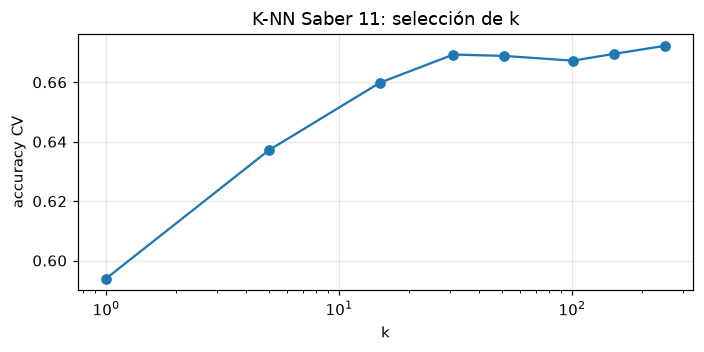

Mejor k = 251

Línea base (clase mayoritaria): accuracy = 0.501
K-NN (k=251): accuracy = 0.675 · ROC-AUC = 0.738 · tiempo de predicción para 7,473 registros = 0.8 s
                  precision    recall  f1-score   support

bajo (< mediana)       0.69      0.63      0.66      3729
alto (≥ mediana)       0.66      0.72      0.69      3744

        accuracy                           0.67      7473
       macro avg       0.68      0.67      0.67      7473
    weighted avg       0.68      0.67      0.67      7473



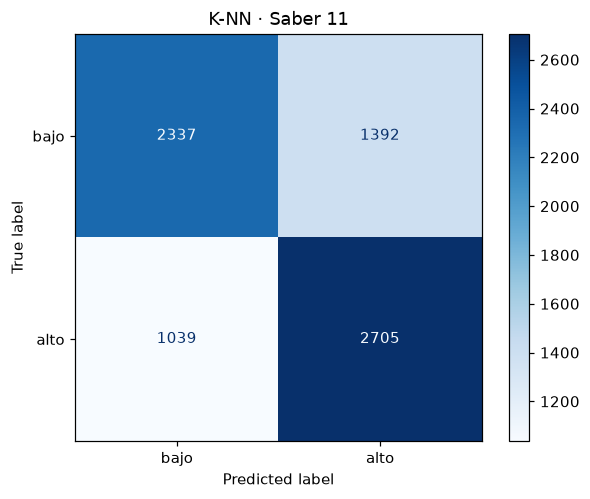

In [44]:
# ============================================================
# 3.5.c K-NN sobre Saber 11: imputación + escalado + búsqueda de k
# ============================================================
pipe_knn_ic = Pipeline([('imp', SimpleImputer(strategy='median')), ('esc', StandardScaler()),
                        ('knn', KNeighborsClassifier())])
# La búsqueda de k usa una submuestra de 15.000 registros: K-NN es O(n) por predicción
sub = np.random.default_rng(SEED).choice(len(X_ic_tr), size=min(15_000, len(X_ic_tr)), replace=False)
ks_ic = [1, 5, 15, 31, 51, 101, 151, 251]
cv_ic = [cross_val_score(pipe_knn_ic.set_params(knn__n_neighbors=k), X_ic_tr.iloc[sub], y_ic_tr[sub],
                         cv=StratifiedKFold(5, shuffle=True, random_state=SEED)).mean() for k in ks_ic]
k_ic = ks_ic[int(np.argmax(cv_ic))]
plt.figure(figsize=(6.5, 3.3)); plt.plot(ks_ic, cv_ic, 'o-'); plt.xscale('log')
plt.xlabel('k'); plt.ylabel('accuracy CV'); plt.title('K-NN Saber 11: selección de k'); plt.tight_layout(); plt.show()
print('Mejor k =', k_ic)

knn_ic = pipe_knn_ic.set_params(knn__n_neighbors=k_ic, knn__weights='uniform').fit(X_ic_tr, y_ic_tr)
t0 = time.perf_counter(); pred_knn_ic = knn_ic.predict(X_ic_te); t_pred_knn = time.perf_counter() - t0
proba_knn_ic = knn_ic.predict_proba(X_ic_te)[:, 1]
base = DummyClassifier(strategy='most_frequent').fit(X_ic_tr, y_ic_tr)

print(f"\nLínea base (clase mayoritaria): accuracy = {base.score(X_ic_te, y_ic_te):.3f}")
print(f"K-NN (k={k_ic}): accuracy = {accuracy_score(y_ic_te, pred_knn_ic):.3f} · "
      f"ROC-AUC = {roc_auc_score(y_ic_te, proba_knn_ic):.3f} · "
      f"tiempo de predicción para {len(X_ic_te):,} registros = {t_pred_knn:.1f} s")
print(classification_report(y_ic_te, pred_knn_ic, target_names=['bajo (< mediana)', 'alto (≥ mediana)']))
ConfusionMatrixDisplay.from_predictions(y_ic_te, pred_knn_ic, display_labels=['bajo', 'alto'], cmap='Blues')
plt.title('K-NN · Saber 11'); plt.grid(False); plt.show()

**Resultados (K-NN, k = 251):**

* **Duplicados:** el conjunto de datos publicado repite casi a cada estudiante dos veces. Sin eliminarlos, K-NN con k = 1 obtenía un 83,5 % falso en el test (frente a 67,5 % en validación cruzada), porque encontraba la *copia exacta* del estudiante en el entrenamiento. Al deduplicar por `estu_consecutivo`, la validación cruzada (0,672) y el test (0,675) coinciden: no hay *data leakage*.
* **Elección de k:** la exactitud sube desde k = 1 (≈59 %) y se estabiliza en ≈67 % a partir de k ≈ 30. Con *features* socioeconómicas, muchos estudiantes comparten perfil pero tienen puntajes muy distintos, así que un k grande promedia ese ruido. Un k pequeño, en cambio, memoriza casos particulares (*overfitting*).
* **Desempeño:** *accuracy* = 0,675 y ROC-AUC = 0,738, frente a 0,501 de la línea base. Las condiciones del hogar y del colegio **sí aportan información** sobre el puntaje, pero no lo determinan: uno de cada tres estudiantes queda mal clasificado.
* **Errores:** el modelo tiende a predecir "alto" (*recall* 0,72 en "alto" vs. 0,63 en "bajo"): 1.392 estudiantes de puntaje bajo fueron clasificados como altos, y 1.039 al revés.
* **Costo:** la predicción de 7.473 registros tomó 0,8 s, porque cada una se compara con todos los registros de entrenamiento. Es la principal desventaja práctica de K-NN.

---
# 4. Ejercicio 4 — Árboles de decisión

> *Estudie el algoritmo de árboles de decisión, con todo detalle mejore su documentación y con base en él haga cambios para una aplicación.*

## 4.1 El algoritmo en detalle (CART)

Un árbol de decisión divide el espacio de *features* en **regiones rectangulares** mediante preguntas binarias del tipo $x_j \le t$. Cada hoja predice la clase mayoritaria de los ejemplos de entrenamiento que caen en ella. Scikit-learn implementa **CART** (*Classification And Regression Trees*).

**Construcción voraz (*greedy*) y recursiva.** En cada nodo con datos $S$:

1. para cada *feature* $j$ y cada umbral candidato $t$ (puntos medios entre valores consecutivos), dividir $S$ en $S_L = \{x_j \le t\}$ y $S_R = \{x_j > t\}$;
2. elegir el par $(j, t)$ que **maximiza la ganancia de impureza**:
$$\Delta I = I(S) - \frac{|S_L|}{|S|} I(S_L) - \frac{|S_R|}{|S|} I(S_R)$$
3. repetir en cada hijo hasta que se cumpla un criterio de parada.

**Medidas de impureza** (con $p_c$ = proporción de la clase $c$ en el nodo):

| Medida | Fórmula | Rango (2 clases) | Comentario |
|---|---|---|---|
| **Gini** | $1 - \sum_c p_c^2$ | [0, 0.5] | Valor por defecto en sklearn; no usa logaritmos, así que es más rápida |
| **Entropía** | $-\sum_c p_c \log_2 p_c$ | [0, 1] | Su ganancia se conoce como *information gain* (ID3/C4.5) |
| Error de clasificación | $1 - \max_c p_c$ | [0, 0.5] | Poco sensible; casi no se usa para construir el árbol |

En la práctica, Gini y entropía producen árboles muy parecidos.

***Overfitting* y regularización.** Un árbol sin límites crece hasta que cada hoja es pura, lo que equivale a memorizar el dataset. Hay dos formas de controlarlo:

* **Pre-poda** (detener el crecimiento): `max_depth`, `min_samples_split`, `min_samples_leaf`, `max_leaf_nodes`, `min_impurity_decrease`.
* **Post-poda por costo-complejidad** (`ccp_alpha`): se hace crecer el árbol completo y luego se poda el subárbol que minimiza
$$R_\alpha(T) = R(T) + \alpha\,|T_{hojas}|$$
donde $R(T)$ es la impureza (o el error) total de las hojas. Un $\alpha$ mayor da un árbol más pequeño, y el valor de $\alpha$ se elige con validación cruzada.

**Importancia de *features* (MDI):** es la suma de las reducciones de impureza ponderadas que aporta cada *feature*. Está **sesgada** hacia las variables con muchos valores posibles, por lo que conviene contrastarla con la *permutation importance*.

**Costo computacional:** el entrenamiento cuesta $\approx O(d\,n \log n)$ y la predicción $O(\text{profundidad})$. Esto es **mucho más rápido que K-NN al predecir**.

**Ventajas:** el modelo es **interpretable** (se lee como reglas *si–entonces*), no requiere escalar las variables, captura interacciones y no linealidades, y su predicción es muy rápida.
**Desventajas:** es inestable (un cambio pequeño en los datos puede cambiar mucho el árbol), sus fronteras son escalonadas y paralelas a los ejes, y tiende al *overfitting*. Los *ensembles* (Random Forest, Gradient Boosting) mitigan estos problemas a cambio de perder interpretabilidad.

## 4.2 Implementación del *split* óptimo desde cero

Se implementan Gini, entropía y la búsqueda del mejor corte, y se verifica que el corte de la **raíz** coincide con el que elige `sklearn`.

In [45]:
# ============================================================
# 4.2 Impureza y mejor split desde cero
# ============================================================
def gini(y):
    if len(y) == 0: return 0.0
    p = np.bincount(y) / len(y)
    return 1 - np.sum(p ** 2)

def entropia(y):
    if len(y) == 0: return 0.0
    p = np.bincount(y) / len(y); p = p[p > 0]
    return -np.sum(p * np.log2(p))

def mejor_split(X, y, impureza=gini):
    """Recorre todas las features y umbrales (puntos medios); devuelve (feature, umbral, ganancia)."""
    mejor = (None, None, -np.inf); I_padre = impureza(y); n = len(y)
    for j in range(X.shape[1]):
        valores = np.unique(X[:, j])
        for t in (valores[:-1] + valores[1:]) / 2:
            izq = X[:, j] <= t
            g = I_padre - izq.mean() * impureza(y[izq]) - (~izq).mean() * impureza(y[~izq])
            if g > mejor[2]: mejor = (j, t, g)
    return mejor

# Ejemplo numérico pequeño (calculable a mano)
y_ej = np.array([0, 0, 0, 1, 1, 1, 1, 1])
print(f"Nodo con 3 'Arriba' y 5 'Abajo': Gini = 1 - (3/8)^2 - (5/8)^2 = {gini(y_ej):.4f} · "
      f"Entropía = {entropia(y_ej):.4f} bits")

# Verificación sobre el dataset de Pong
for nombre, imp, crit in [('Gini', gini, 'gini'), ('Entropía', entropia, 'entropy')]:
    j, t, g = mejor_split(X_pong, y_pong, imp)
    arbol1 = DecisionTreeClassifier(max_depth=1, criterion=crit, random_state=SEED).fit(X_pong, y_pong)
    print(f"{nombre:8s} desde cero: {FEATS[j]} <= {t:.2f} (ganancia {g:.4f})   |   sklearn: "
          f"{FEATS[arbol1.tree_.feature[0]]} <= {arbol1.tree_.threshold[0]:.2f}")

Nodo con 3 'Arriba' y 5 'Abajo': Gini = 1 - (3/8)^2 - (5/8)^2 = 0.4688 · Entropía = 0.9544 bits
Gini     desde cero: dif_y <= 1.50 (ganancia 0.0629)   |   sklearn: dif_y <= 1.50
Entropía desde cero: dif_y <= 1.50 (ganancia 0.0928)   |   sklearn: dif_y <= 1.50


## 4.3 Aplicación a Pong: profundidad, poda y reglas

Primero se estudia cómo cambia la exactitud (en entrenamiento y en validación cruzada) con `max_depth`, con y sin la *feature* `dif_y`. Después se busca la mejor combinación de hiperparámetros, incluida la post-poda `ccp_alpha`.

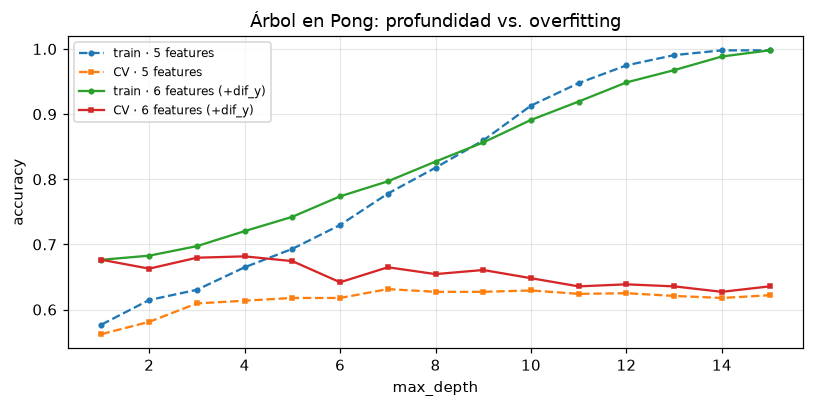

Mejor árbol: CV accuracy = 0.696 con {'ccp_alpha': 0.0, 'criterion': 'entropy', 'max_depth': 4, 'min_samples_leaf': 20}
  profundidad real = 4, hojas = 14


In [46]:
# ============================================================
# 4.3 Curvas de complejidad y GridSearch del árbol
# ============================================================
profs = list(range(1, 16))
fig, ax = plt.subplots(figsize=(7.5, 3.8))
for nombre, cols, est in [('5 features', slice(0, 5), '--'), ('6 features (+dif_y)', slice(0, 6), '-')]:
    tr, cv = [], []
    for d in profs:
        m = DecisionTreeClassifier(max_depth=d, random_state=SEED)
        cv.append(cross_val_score(m, X_pong[:, cols], y_pong, cv=cv5).mean())
        tr.append(m.fit(X_pong[:, cols], y_pong).score(X_pong[:, cols], y_pong))
    ax.plot(profs, tr, est, marker='o', ms=3, label=f'train · {nombre}')
    ax.plot(profs, cv, est, marker='s', ms=3, label=f'CV · {nombre}')
ax.set_xlabel('max_depth'); ax.set_ylabel('accuracy'); ax.legend(fontsize=8)
ax.set_title('Árbol en Pong: profundidad vs. overfitting'); plt.tight_layout(); plt.show()

grid_tree = {'max_depth': [2, 3, 4, 5, 6, 8, 10, None], 'min_samples_leaf': [1, 3, 5, 10, 20],
             'criterion': ['gini', 'entropy'], 'ccp_alpha': [0.0, 0.001, 0.003, 0.01]}
gs_tree = GridSearchCV(DecisionTreeClassifier(random_state=SEED), grid_tree, cv=cv5, n_jobs=-1).fit(X_pong, y_pong)
tree_best = gs_tree.best_estimator_
print(f"Mejor árbol: CV accuracy = {gs_tree.best_score_:.3f} con {gs_tree.best_params_}")
print(f"  profundidad real = {tree_best.get_depth()}, hojas = {tree_best.get_n_leaves()}")

|--- dif_y <= 1.50
|   |--- dif_y <= -3.50
|   |   |--- pelota_x <= 3.50
|   |   |   |--- class: Arriba
|   |   |--- pelota_x >  3.50
|   |   |   |--- class: Abajo
|   |--- dif_y >  -3.50
|   |   |--- dir_y <= 0.50
|   |   |   |--- class: Abajo
|   |   |--- dir_y >  0.50
|   |   |   |--- class: Abajo
|--- dif_y >  1.50
|   |--- dif_y <= 7.50
|   |   |--- dir_y <= 0.50
|   |   |   |--- class: Arriba
|   |   |--- dir_y >  0.50
|   |   |   |--- class: Arriba
|   |--- dif_y >  7.50
|   |   |--- pelota_x <= 4.50
|   |   |   |--- class: Abajo
|   |   |--- pelota_x >  4.50
|   |   |   |--- class: Arriba



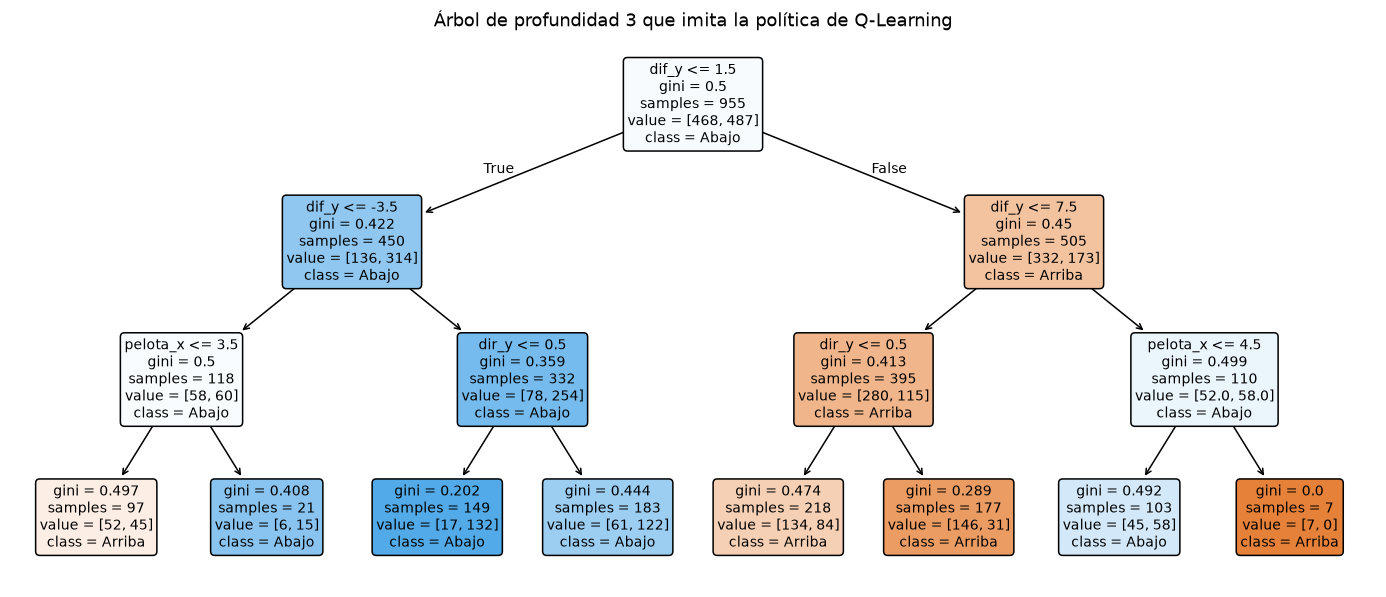

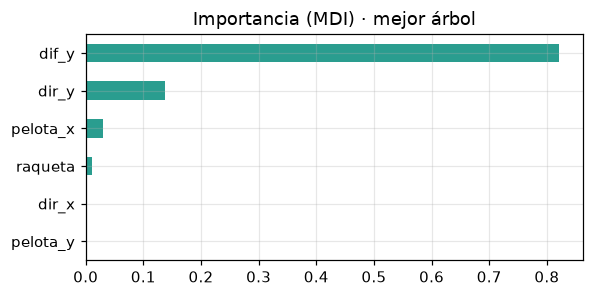

In [47]:
# ============================================================
# Reglas legibles: árbol de profundidad 3
# ============================================================
tree3 = DecisionTreeClassifier(max_depth=3, random_state=SEED).fit(X_pong, y_pong)
print(export_text(tree3, feature_names=FEATS, class_names=['Arriba', 'Abajo']))
fig, ax = plt.subplots(figsize=(16, 6.5))
plot_tree(tree3, ax=ax, feature_names=FEATS, class_names=['Arriba', 'Abajo'], filled=True, rounded=True,
          impurity=True, proportion=False, fontsize=9)
plt.title('Árbol de profundidad 3 que imita la política de Q-Learning'); plt.show()

imp = pd.Series(tree_best.feature_importances_, index=FEATS).sort_values()
fig, ax = plt.subplots(figsize=(5.5, 2.8))
imp.plot.barh(ax=ax, color='#2a9d8f', title='Importancia (MDI) · mejor árbol'); plt.tight_layout(); plt.show()

**Lectura del árbol.** El primer corte, elegido de forma idéntica por la implementación desde cero y por sklearn, es **`dif_y <= 1.5`**, que significa “la pelota está por debajo del centro de la raqueta”:

* `dif_y ≤ 1.5` (pelota abajo) → **Abajo**;
* `1.5 < dif_y ≤ 7.5` (pelota arriba) → **Arriba**.

Estas dos ramas resumen toda la estrategia, y el umbral de 1,5 *bins* coincide con la mitad de la altura de la paleta. Los demás cortes (`pelota_x`, `dir_y`) solo refinan casos de borde, como pelotas muy lejanas en vertical. Un árbol de 8 hojas resume así una Q-table de 19.456 × 2 valores. Gracias a `dif_y`, el corte principal es un solo umbral; con las variables originales, el árbol tendría que aproximar la diagonal con una “escalera” de muchos cortes.

                                                     golpes/episodio  vidas perdidas/episodio  golpes por vida perdida
política                                                                                                              
Q-Learning (maestro)                                           59.82                     0.21                   284.86
Árbol mejor (GridSearch)                                       59.82                     0.21                   284.86
Árbol profundidad 3                                            59.82                     0.21                   284.86
Árbol como en clase (todos los estados, sin límite)            59.82                     0.21                   284.86


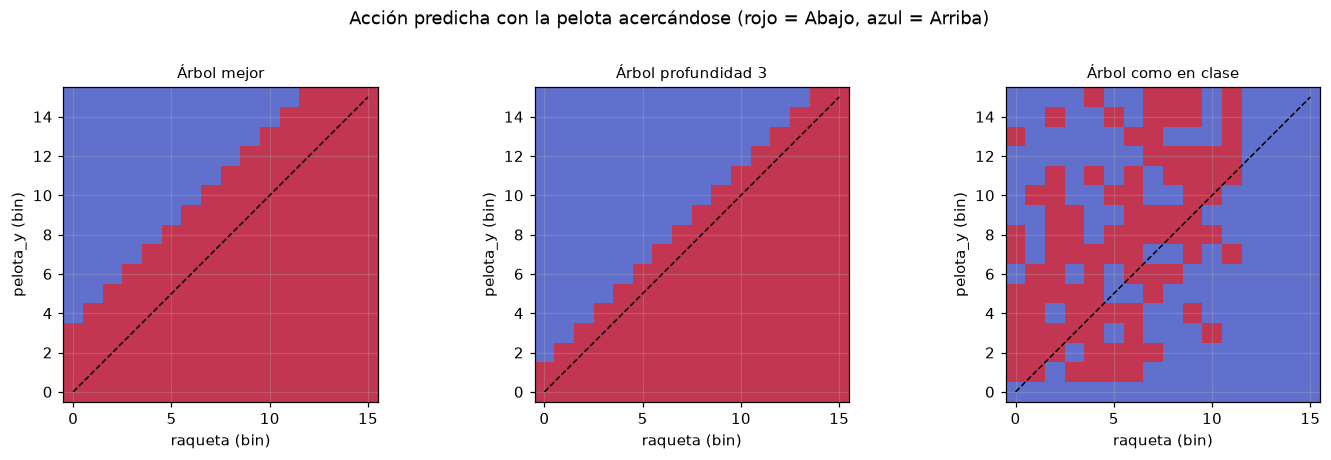

In [48]:
# ============================================================
# 4.4 ¿El árbol juega bien?
# ============================================================
tree_orig = DecisionTreeClassifier(random_state=42).fit(features_pong(idx_all)[:, :5], y_all)   # como en clase
class _Adaptador:                                   # el árbol original solo usa las 5 variables del estado
    def __init__(self, m): self.m = m
    def predict(self, X): return self.m.predict(X[:, :5])

filas = [{'política': 'Q-Learning (maestro)', **ref_q},
         {'política': 'Árbol mejor (GridSearch)', **evaluar(tabla_de_politica(tree_best))},
         {'política': 'Árbol profundidad 3', **evaluar(tabla_de_politica(tree3))},
         {'política': 'Árbol como en clase (todos los estados, sin límite)', **evaluar(tabla_de_politica(_Adaptador(tree_orig)))}]
res_tree_juego = pd.DataFrame(filas).set_index('política')
print(res_tree_juego.round(2).to_string())

fig, axs = plt.subplots(1, 3, figsize=(13, 4))
plot_frontera(tree_best, axs[0], 'Árbol mejor')
plot_frontera(tree3, axs[1], 'Árbol profundidad 3')
plot_frontera(_Adaptador(tree_orig), axs[2], 'Árbol como en clase')
fig.suptitle('Acción predicha con la pelota acercándose (rojo = Abajo, azul = Arriba)', y=1.02)
plt.tight_layout(); plt.show()

**Resultado:** todos los árboles juegan igual que el maestro, **incluido el árbol entrenado como en clase**. Hay una razón concreta, que marca una diferencia importante con K-NN:

* El árbol de clase se entrena con **todos** los estados de la tabla y **sin límite de profundidad**, así que se convierte en una **copia exacta de la tabla** (*lookup table*). En los estados que el agente visita, reproduce la acción del maestro. Su frontera es ruidosa solo en estados que el juego casi nunca alcanza, como se ve en la tercera gráfica. Ese árbol no generaliza: **memoriza**.
* El K-NN de clase, en cambio, **promedia con los vecinos**, y como estos suelen ser estados con etiqueta basura, contaminan las decisiones en estados reales.
* El árbol de profundidad 3, con 8 hojas, juega igual de bien, y es la opción realmente útil: es **interpretable y compacto**, y además **generaliza** a estados nunca vistos, con una frontera diagonal limpia.

## 4.5 Árbol de decisión sobre Saber 11 (ICFES)

Se usa el mismo dataset de la sección 3.5. El árbol no necesita escalado, pero sí imputación de los valores faltantes. La profundidad se controla con **post-poda por costo-complejidad**: se calcula la ruta de poda (`cost_complexity_pruning_path`) y se elige $\alpha$ por validación cruzada.

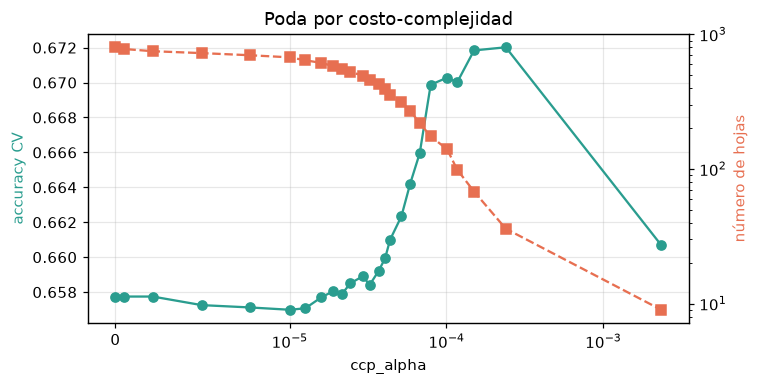

alpha* = 2.39e-04 -> profundidad 10, 36 hojas
Árbol podado: accuracy = 0.669 · ROC-AUC = 0.736 · predicción en 1.4 ms
                  precision    recall  f1-score   support

bajo (< mediana)       0.65      0.71      0.68      3729
alto (≥ mediana)       0.69      0.63      0.65      3744

        accuracy                           0.67      7473
       macro avg       0.67      0.67      0.67      7473
    weighted avg       0.67      0.67      0.67      7473



In [49]:
# ============================================================
# 4.5.a Poda por costo-complejidad
# ============================================================
imputador = SimpleImputer(strategy='median').fit(X_ic_tr)
Xi_tr, Xi_te = imputador.transform(X_ic_tr), imputador.transform(X_ic_te)
cols_ic = list(X_ic.columns)

ruta = DecisionTreeClassifier(random_state=SEED, min_samples_leaf=20).cost_complexity_pruning_path(Xi_tr, y_ic_tr)
alphas = np.unique(np.quantile(ruta.ccp_alphas, np.linspace(0, 0.99, 25)))
cv_a, hojas = [], []
for a in alphas:
    m = DecisionTreeClassifier(random_state=SEED, min_samples_leaf=20, ccp_alpha=a)
    cv_a.append(cross_val_score(m, Xi_tr, y_ic_tr, cv=StratifiedKFold(5, shuffle=True, random_state=SEED)).mean())
    hojas.append(m.fit(Xi_tr, y_ic_tr).get_n_leaves())
a_best = alphas[int(np.argmax(cv_a))]

fig, ax1 = plt.subplots(figsize=(7, 3.6)); ax2 = ax1.twinx()
ax1.plot(alphas, cv_a, 'o-', color='#2a9d8f'); ax2.plot(alphas, hojas, 's--', color='#e76f51')
ax1.set_xscale('symlog', linthresh=1e-5); ax1.set_xlabel('ccp_alpha'); ax1.set_ylabel('accuracy CV', color='#2a9d8f')
ax2.set_ylabel('número de hojas', color='#e76f51'); ax2.set_yscale('log'); ax2.grid(False)
plt.title('Poda por costo-complejidad'); plt.tight_layout(); plt.show()

tree_ic = DecisionTreeClassifier(random_state=SEED, min_samples_leaf=20, ccp_alpha=a_best).fit(Xi_tr, y_ic_tr)
t0 = time.perf_counter(); pred_tree_ic = tree_ic.predict(Xi_te); t_pred_tree = time.perf_counter() - t0
proba_tree_ic = tree_ic.predict_proba(Xi_te)[:, 1]
print(f"alpha* = {a_best:.2e} -> profundidad {tree_ic.get_depth()}, {tree_ic.get_n_leaves()} hojas")
print(f"Árbol podado: accuracy = {accuracy_score(y_ic_te, pred_tree_ic):.3f} · ROC-AUC = "
      f"{roc_auc_score(y_ic_te, proba_tree_ic):.3f} · predicción en {t_pred_tree*1e3:.1f} ms")
print(classification_report(y_ic_te, pred_tree_ic, target_names=['bajo (< mediana)', 'alto (≥ mediana)']))

**Resultados del árbol podado:**

* **Efecto de la poda:** sin poda (α = 0) el árbol tiene ≈800 hojas y una *accuracy* CV de 0,658, porque memoriza casos particulares (*overfitting*). Con α* = 2,4·10⁻⁴ queda en **36 hojas** (profundidad 10) y sube a 0,672. Con una poda excesiva (9 hojas) cae a 0,661 por *underfitting*. Un árbol 20 veces más pequeño generaliza mejor.
* **Desempeño en test:** *accuracy* = 0,669 y ROC-AUC = 0,736, prácticamente igual que K-NN (0,675 / 0,738). La diferencia está dentro del error estadístico (≈ ±0,5 puntos con 7.473 registros).
* **Velocidad:** el árbol predijo los 7.473 registros en 1,4 ms, frente a 800 ms de K-NN (≈570× más rápido): recorre a lo sumo 10 nodos en lugar de calcular la distancia a todos los registros de entrenamiento.
* **Errores complementarios:** el árbol tiende a predecir "bajo" (*recall* 0,71 en "bajo" vs. 0,63 en "alto"), al contrario de K-NN. Que dos algoritmos tan distintos lleguen al mismo techo (≈67 %) indica que **el límite está en la información disponible y no en el modelo**: el puntaje depende en gran parte de factores que no están en estas variables.

Árbol de profundidad 3 (accuracy test = 0.612):

|--- edu_madre <= 4.50
|   |--- jornada_SABATINA <= 0.50
|   |   |--- jornada_NOCHE <= 0.50
|   |   |   |--- class: bajo
|   |   |--- jornada_NOCHE >  0.50
|   |   |   |--- class: bajo
|   |--- jornada_SABATINA >  0.50
|   |   |--- estrato <= 2.50
|   |   |   |--- class: bajo
|   |   |--- estrato >  2.50
|   |   |   |--- class: bajo
|--- edu_madre >  4.50
|   |--- jornada_COMPLETA <= 0.50
|   |   |--- jornada_NOCHE <= 0.50
|   |   |   |--- class: alto
|   |   |--- jornada_NOCHE >  0.50
|   |   |   |--- class: bajo
|   |--- jornada_COMPLETA >  0.50
|   |   |--- colegio_oficial <= 0.50
|   |   |   |--- class: alto
|   |   |--- colegio_oficial >  0.50
|   |   |   |--- class: alto



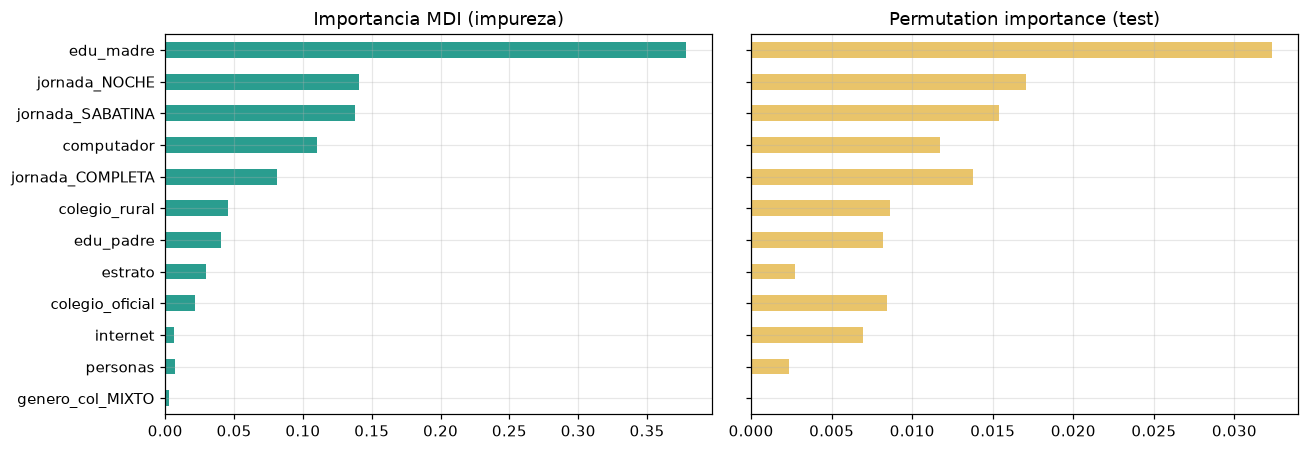

In [50]:
# ============================================================
# 4.5.b Interpretación: reglas e importancia de variables
# ============================================================
tree_ic3 = DecisionTreeClassifier(max_depth=3, min_samples_leaf=50, random_state=SEED).fit(Xi_tr, y_ic_tr)
print(f"Árbol de profundidad 3 (accuracy test = {tree_ic3.score(Xi_te, y_ic_te):.3f}):\n")
print(export_text(tree_ic3, feature_names=cols_ic, class_names=['bajo', 'alto']))

mdi = pd.Series(tree_ic.feature_importances_, index=cols_ic)
perm = permutation_importance(tree_ic, Xi_te, y_ic_te, n_repeats=5, random_state=SEED, n_jobs=-1)
perm = pd.Series(perm.importances_mean, index=cols_ic)
top = mdi.add(perm, fill_value=0).sort_values(ascending=False).index[:12][::-1]
fig, ax = plt.subplots(1, 2, figsize=(12, 4.2), sharey=True)
mdi[top].plot.barh(ax=ax[0], color='#2a9d8f', title='Importancia MDI (impureza)')
perm[top].plot.barh(ax=ax[1], color='#e9c46a', title='Permutation importance (test)')
plt.tight_layout(); plt.show()

**Interpretación del árbol y de las importancias:**

* **Reglas (árbol de profundidad 3, accuracy = 0,612):** en la práctica el árbol hace dos preguntas: (1) ¿la madre tiene educación posterior al bachillerato (`edu_madre > 4,5`)? Si no, predice "bajo". (2) Si sí, ¿el colegio es de jornada nocturna? Si lo es, "bajo"; si no, "alto". Algunos cortes no cambian la clase predicha (por ejemplo, `jornada_SABATINA` lleva a "bajo" en ambas ramas): el árbol los hace porque **reducen la impureza** (Gini) aunque la mayoría siga siendo la misma.
* **Educación de la madre:** es la variable dominante según ambos métodos (MDI ≈ 0,38; permutarla reduce la *accuracy* en 3,2 puntos).
* **Jornada:** las jornadas nocturna y sabatina, que suelen atender a adultos y estudiantes en extraedad, se asocian con puntajes menores. Esto refleja las condiciones de estudio de esa población, no un efecto de la jornada en sí.
* **El estrato casi no aparece** (*permutation importance* ≈ 0,003), aunque está fuertemente asociado al puntaje. La razón es que está **correlacionado** con la educación de los padres, el acceso a computador y el tipo de colegio: al permutarlo, el modelo compensa con esas variables. **La importancia mide cuánto depende el modelo de una variable, no su efecto causal**, y entre variables correlacionadas la importancia se reparte de forma arbitraria.
* **MDI vs. permutación:** coinciden en las variables principales, lo que da solidez al resultado. Difieren en `colegio_oficial` e `internet`, que se usan en pocos nodos (MDI bajo) pero afectan a muchas predicciones (permutación moderada).

---
# 5. Comparación final y conclusiones

## 5.1 K-NN vs. árbol de decisión en las dos aplicaciones

In [51]:
# ============================================================
# 5.1 Resumen Pong
# ============================================================
resumen_pong = pd.DataFrame({
    'CV accuracy (dataset limpio)': [np.nan, resultados_knn['6 features (+ dif_y)'].best_score_, gs_tree.best_score_],
    'golpes/episodio': [ref_q['golpes/episodio'], res_knn_juego.loc['K-NN mejor (GridSearch)', 'golpes/episodio'],
                        res_tree_juego.loc['Árbol mejor (GridSearch)', 'golpes/episodio']],
    'vidas perdidas/episodio': [ref_q['vidas perdidas/episodio'],
                                res_knn_juego.loc['K-NN mejor (GridSearch)', 'vidas perdidas/episodio'],
                                res_tree_juego.loc['Árbol mejor (GridSearch)', 'vidas perdidas/episodio']],
}, index=['Q-Learning (tabla)', 'K-NN', 'Árbol de decisión'])
print(resumen_pong.round(3).to_string())

                    CV accuracy (dataset limpio)  golpes/episodio  vidas perdidas/episodio
Q-Learning (tabla)                           NaN            59.82                     0.21
K-NN                                       0.688            59.82                     0.21
Árbol de decisión                          0.696            59.82                     0.21


In [52]:
# ============================================================
# 5.2 Resumen Saber 11 + auditoría de sesgo ("ML oscura", sección 6.11)
# ============================================================
resumen_ic = pd.DataFrame({
    'accuracy': [base.score(X_ic_te, y_ic_te), accuracy_score(y_ic_te, pred_knn_ic), accuracy_score(y_ic_te, pred_tree_ic)],
    'ROC-AUC': [0.5, roc_auc_score(y_ic_te, proba_knn_ic), roc_auc_score(y_ic_te, proba_tree_ic)],
    'tiempo de predicción [s]': [np.nan, t_pred_knn, t_pred_tree],
}, index=['Línea base', f'K-NN (k={k_ic})', 'Árbol podado'])
print(resumen_ic.round(3).to_string())

# ¿El modelo trata distinto a grupos que NO usó como feature?
audit = pd.DataFrame({'real': y_ic_te, 'pred_arbol': pred_tree_ic, 'genero': g_te, 'naturaleza': nat_te})
for grupo in ['genero', 'naturaleza']:
    t = audit.groupby(grupo).agg(n=('real', 'size'), tasa_real_alto=('real', 'mean'),
                                tasa_predicha_alto=('pred_arbol', 'mean'))
    t['accuracy'] = audit.groupby(grupo).apply(lambda g: (g.real == g.pred_arbol).mean())
    print(f"\nPor {grupo}:\n", t.round(3).to_string())

              accuracy  ROC-AUC  tiempo de predicción [s]
Línea base       0.501    0.500                       NaN
K-NN (k=251)     0.675    0.738                     0.847
Árbol podado     0.669    0.736                     0.001

Por genero:
            n  tasa_real_alto  tasa_predicha_alto  accuracy
genero                                                    
F       4039           0.471               0.452     0.682
M       3432           0.537               0.464     0.654

Por naturaleza:
                n  tasa_real_alto  tasa_predicha_alto  accuracy
naturaleza                                                    
NO OFICIAL  1793           0.606               0.592     0.753
OFICIAL     5680           0.468               0.415     0.642


**Auditoría por grupos:**

| | K-NN (k=251) | Árbol podado |
|---|---|---|
| Accuracy | 0,675 | 0,669 |
| ROC-AUC | 0,738 | 0,736 |
| Tiempo de predicción | 0,847 s | 0,001 s |

* **Naturaleza del colegio (el modelo amplifica la desigualdad):** la brecha real en la tasa de puntaje "alto" entre colegios no oficiales (60,6 %) y oficiales (46,8 %) es de 13,8 puntos, pero el árbol predice una brecha de **17,7 puntos** (59,2 % vs. 41,5 %). El modelo **subestima a los estudiantes de colegios oficiales** (−5,3 puntos) y además se equivoca más con ellos (*accuracy* 0,642 vs. 0,753), aunque son el 76 % de la muestra. La causa es la regla de mayoría en las hojas: en los grupos donde "alto" es minoría, el modelo tiende a predecir "bajo" para todos.
* **Género (excluirlo no basta):** el género no se usó como *feature*, y el modelo casi no distingue entre grupos (45,2 % vs. 46,4 % de "alto" predicho), aunque la tasa real difiere en 6,6 puntos (47,1 % vs. 53,7 %). Por eso subestima a los hombres (−7,3 puntos) y tiene menor *accuracy* con ellos (0,654 vs. 0,682). Quitar la variable sensible (*fairness through unawareness*) no garantiza un trato equitativo: hay que auditar por grupo.

## 5.3 Conclusiones

**Ejercicio 1 (matrices).** ML solo recupera una regla exacta cuando su espacio de hipótesis la contiene: la regresión polinómica de grado 2 la reproduce sin error, mientras que la MLP solo la aproxima. Cuando la regla es conocida, el cálculo analítico es órdenes de magnitud más barato (sección 1.8).

**Ejercicios 3 y 4 sobre Pong:**

1. **La mayor ganancia vino de los datos, no del clasificador.** Al corregir los índices negativos e incluir la dirección de la pelota, el maestro (Q-Learning) pasa de un desempeño mediocre y variable a uno casi óptimo. Al construir el dataset solo con estados visitados y decisivos, se eliminan las etiquetas falsas de “Arriba”.
2. **La *accuracy* contra la Q-table es una métrica engañosa.** Los estados donde la acción da igual inflan el error sin afectar el juego. La métrica correcta es **jugar**.
3. ***Feature engineering*:** `dif_y` convierte la frontera diagonal en un problema de un solo umbral. Esto ayuda sobre todo al árbol, que solo puede cortar paralelo a los ejes, y lo vuelve muy legible: “si la pelota está por encima de la raqueta, subir”.
4. **K-NN vs. árbol:** con el dataset limpio y los hiperparámetros elegidos por CV, ambos juegan igual que el maestro (≈60 golpes por episodio). K-NN es **sensible** a $k$ y a la calidad de las etiquetas: con $k=1$, o con el dataset de clase, se desploma a ≈8–12 golpes. El árbol ofrece **reglas interpretables** (`dif_y ≤ 1.5 → Abajo`) y una predicción en $O(\text{profundidad})$; K-NN no tiene fase de entrenamiento, pero cada predicción cuesta $O(n)$. Para un robot o microcontrolador, el árbol pequeño, o la política “compilada” en tabla, es lo más adecuado.

**Ejercicios 3 y 4 sobre Saber 11 (datos.gov.co):**

* **Calidad de datos:** el conjunto publicado repite a casi cada estudiante dos veces. Sin deduplicar, K-NN con k = 1 aparentaba un 83,5 % de *accuracy* por *data leakage*; el valor real es 67,5 %. Un resultado "demasiado bueno", o que no coincide con la validación cruzada, debe revisarse antes de creerlo.
* **Desempeño:** K-NN (0,675) y el árbol podado (0,669) empatan dentro del error estadístico, frente al 0,501 de la línea base. Que dos algoritmos tan distintos lleguen al mismo techo indica que el límite está en la información disponible: el entorno socioeconómico **influye** en el puntaje, pero **no lo determina**. El árbol es ≈850 veces más rápido al predecir y además es interpretable.
* **Qué aprendió el modelo:** la variable dominante es la **educación de la madre**, seguida de la jornada del colegio (nocturna y sabatina se asocian a puntajes menores) y el acceso a computador. El estrato casi no aparece porque su información ya está contenida en variables correlacionadas: **la importancia no es causalidad**.
* **ML oscura (sección 6.11):** el modelo **amplifica** la brecha entre colegios oficiales y no oficiales (13,8 puntos reales vs. 17,7 predichos) y se equivoca más con los estudiantes de colegios públicos. Usarlo para decidir sobre personas (becas, admisiones) castigaría a los estudiantes por su origen, más allá incluso de lo que reflejan los datos, y perpetuaría la desigualdad, como en el caso de Amazon que menciona la guía. Además, excluir el género no evitó tasas de error distintas entre hombres y mujeres.